# Online Retail II — Data Preparation & ETL

## 1. Imports

In [1]:
from pathlib import Path
import zipfile
import shutil
import numpy as np
import pandas as pd


## 2. Paths

In [2]:
from pathlib import Path

ZIP_PATH = Path(r"data/online+retail+ii.zip")

BASE_DIR = Path.cwd()
EXTRACT_DIR = BASE_DIR / "online_retail_ii_raw"
OUTPUT_DIR = BASE_DIR / "online_retail_ii_processed"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 3. Extract

In [3]:
if not ZIP_PATH.exists():
    raise FileNotFoundError(f"ZIP file not found: {ZIP_PATH}")

if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print("Extraction completed.")


Extraction completed.


## 4. Load

In [4]:
files = list(EXTRACT_DIR.rglob("*.xlsx")) + list(EXTRACT_DIR.rglob("*.xls")) + list(EXTRACT_DIR.rglob("*.csv"))

if not files:
    raise FileNotFoundError("No Excel or CSV file found after extraction.")

data_file = max(files, key=lambda p: p.stat().st_size)
print("Selected file:", data_file)

if data_file.suffix.lower() in [".xlsx", ".xls"]:
    sheets = pd.read_excel(data_file, sheet_name=None)
    retail_df = pd.concat(sheets.values(), ignore_index=True)
else:
    retail_df = pd.read_csv(data_file)

print("Shape:", retail_df.shape)
retail_df.head()


Selected file: d:\AI_training\projct_2\projct\online_retail_ii_raw\online_retail_II.xlsx
Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 5. Standardize Columns

In [5]:
column_map = {
    "Invoice": "invoice_no",
    "InvoiceNo": "invoice_no",
    "StockCode": "stock_code",
    "Description": "description",
    "Quantity": "quantity",
    "InvoiceDate": "invoice_date",
    "Price": "unit_price",
    "UnitPrice": "unit_price",
    "Customer ID": "customer_id",
    "CustomerID": "customer_id",
    "Country": "country"
}

retail_df = retail_df.rename(columns=column_map)
retail_df.columns = [
    str(col).strip().lower().replace(" ", "_").replace("-", "_")
    for col in retail_df.columns
]

retail_df.head()


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 6. Data Quality

In [6]:
quality_report = pd.DataFrame({
    "column": retail_df.columns,
    "dtype": retail_df.dtypes.astype(str).values,
    "missing_count": retail_df.isna().sum().values,
    "missing_percent": (retail_df.isna().mean() * 100).round(2).values,
    "unique_values": retail_df.nunique(dropna=True).values
})

quality_report


,column,dtype,missing_count,missing_percent,unique_values
0,invoice_no,object,0,0.00,53628
1,stock_code,object,0,0.00,5305
2,description,object,4382,0.41,5698
3,quantity,int64,0,0.00,1057
4,invoice_date,datetime64[ns],0,0.00,47635
5,unit_price,float64,0,0.00,2807
6,customer_id,float64,243007,22.77,5942
7,country,object,0,0.00,43


## 7. Remove Duplicates

In [7]:
before_duplicates = len(retail_df)

retail_df = retail_df.drop_duplicates().reset_index(drop=True)

after_duplicates = len(retail_df)
removed_duplicates = before_duplicates - after_duplicates

print("Rows before:", before_duplicates)
print("Duplicates removed:", removed_duplicates)
print("Rows after:", after_duplicates)


Rows before: 1067371
Duplicates removed: 34335
Rows after: 1033036


## 8. Convert Data Types

In [8]:
retail_df["invoice_no"] = retail_df["invoice_no"].astype("string").str.strip()
retail_df["stock_code"] = retail_df["stock_code"].astype("string").str.strip()
retail_df["description"] = retail_df["description"].astype("string").str.strip()
retail_df["country"] = retail_df["country"].astype("string").str.strip()

retail_df["quantity"] = pd.to_numeric(retail_df["quantity"], errors="coerce")
retail_df["unit_price"] = pd.to_numeric(retail_df["unit_price"], errors="coerce")
retail_df["customer_id"] = pd.to_numeric(retail_df["customer_id"], errors="coerce")
retail_df["invoice_date"] = pd.to_datetime(retail_df["invoice_date"], errors="coerce")

print(retail_df.dtypes)


invoice_no      string[python]
stock_code      string[python]
description     string[python]
quantity                 int64
invoice_date    datetime64[ns]
unit_price             float64
customer_id            float64
country         string[python]
dtype: object


## 9. Handle Missing Values

In [9]:
required_columns = [
    "invoice_no",
    "stock_code",
    "quantity",
    "invoice_date",
    "unit_price"
]

retail_df = retail_df.dropna(subset=required_columns).reset_index(drop=True)

retail_df["description"] = retail_df["description"].fillna("Unknown")
retail_df["country"] = retail_df["country"].fillna("Unknown")

print("Shape after missing-value handling:", retail_df.shape)
print(retail_df.isna().sum())


Shape after missing-value handling: (1033036, 8)
invoice_no           0
stock_code           0
description          0
quantity             0
invoice_date         0
unit_price           0
customer_id     235151
country              0
dtype: int64


## 10. Transaction Transformation

In [10]:
retail_df["is_return"] = retail_df["quantity"] < 0
retail_df["is_cancelled"] = retail_df["invoice_no"].str.upper().str.startswith("C", na=False)

retail_df["revenue"] = retail_df["quantity"] * retail_df["unit_price"]
retail_df["absolute_revenue"] = retail_df["revenue"].abs()

retail_df["invoice_no"] = retail_df["invoice_no"].astype("string")


## 11. Date Features

In [11]:
retail_df["invoice_year"] = retail_df["invoice_date"].dt.year
retail_df["invoice_month"] = retail_df["invoice_date"].dt.month
retail_df["invoice_day"] = retail_df["invoice_date"].dt.day
retail_df["invoice_day_name"] = retail_df["invoice_date"].dt.day_name()
retail_df["invoice_hour"] = retail_df["invoice_date"].dt.hour
retail_df["invoice_date_only"] = retail_df["invoice_date"].dt.date


## 12. Customer Features

In [12]:
customer_base = retail_df[retail_df["customer_id"].notna()].copy()

customer_features = customer_base.groupby("customer_id").agg(
    first_purchase=("invoice_date", "min"),
    last_purchase=("invoice_date", "max"),
    total_orders=("invoice_no", "nunique"),
    total_items=("quantity", "sum"),
    total_revenue=("revenue", "sum"),
    average_transaction_value=("revenue", "mean"),
    unique_products=("stock_code", "nunique"),
    unique_countries=("country", "nunique"),
    return_count=("is_return", "sum")
).reset_index()

customer_features["lifetime_days"] = (
    customer_features["last_purchase"] -
    customer_features["first_purchase"]
).dt.days

customer_features.head()


,customer_id,first_purchase,last_purchase,total_orders,total_items,total_revenue,average_transaction_value,unique_products,unique_countries,return_count,lifetime_days
0,12346.0,2009-12-14 08:34:00,2011-01-18 10:17:00,17,53,-51.74,-1.100851,30,1,13,400
1,12347.0,2010-10-31 14:20:00,2011-12-07 15:52:00,8,2967,4921.53,22.169054,126,1,0,402
2,12348.0,2010-09-27 14:59:00,2011-09-25 13:13:00,5,2714,2019.40,39.596078,25,1,0,362
3,12349.0,2009-12-04 12:49:00,2011-11-21 09:51:00,5,1619,4404.54,24.469667,139,1,5,716
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,197,334.40,19.670588,17,1,0,0


## 13. Product Features

In [13]:
product_features = retail_df.groupby("stock_code").agg(
    total_quantity=("quantity", "sum"),
    total_revenue=("revenue", "sum"),
    invoice_count=("invoice_no", "nunique"),
    customer_count=("customer_id", "nunique"),
    return_count=("is_return", "sum")
).reset_index()

product_features = product_features.merge(
    retail_df[["stock_code", "description"]]
    .drop_duplicates("stock_code"),
    on="stock_code",
    how="left"
)

product_features.head()


,stock_code,total_quantity,total_revenue,invoice_count,customer_count,return_count,description
0,10002,7625,6058.71,371,164,8,INFLATABLE POLITICAL GLOBE
1,10002R,4,20.57,3,0,0,ROBOT PENCIL SHARPNER
2,10080,597,129.29,30,23,0,GROOVY CACTUS INFLATABLE
3,10109,0,1.68,2,1,1,BENDY COLOUR PENCILS
4,10120,-8366,136.44,75,52,2,DOGGY RUBBER


## 14. Daily Sales

In [14]:
daily_sales = retail_df.groupby("invoice_date_only").agg(
    revenue=("revenue", "sum"),
    quantity=("quantity", "sum"),
    invoices=("invoice_no", "nunique"),
    customers=("customer_id", "nunique")
).reset_index()

daily_sales["invoice_date_only"] = pd.to_datetime(daily_sales["invoice_date_only"])

daily_sales.head()


,invoice_date_only,revenue,quantity,invoices,customers
0,2009-12-01,53010.76,23916,166,117
1,2009-12-02,62583.66,29850,133,98
2,2009-12-03,68027.59,44874,150,116
3,2009-12-04,40195.80,20886,107,82
4,2009-12-05,9803.05,5033,32,26


## 15. Save Processed Data

In [15]:
retail_df.to_csv(OUTPUT_DIR / "transactions_clean.csv", index=False)
customer_features.to_csv(OUTPUT_DIR / "customer_features.csv", index=False)
product_features.to_csv(OUTPUT_DIR / "product_features.csv", index=False)
daily_sales.to_csv(OUTPUT_DIR / "daily_sales.csv", index=False)
quality_report.to_csv(OUTPUT_DIR / "data_quality_report.csv", index=False)

print("Files saved to:", OUTPUT_DIR)


Files saved to: d:\AI_training\projct_2\projct\online_retail_ii_processed


## 16. Data Dictionary

In [16]:
data_dictionary = pd.DataFrame({
    "column": retail_df.columns,
    "description": [
        "Transaction invoice number",
        "Product stock code",
        "Product description",
        "Purchased quantity",
        "Invoice date and time",
        "Unit price",
        "Customer identifier",
        "Customer country",
        "Return indicator",
        "Cancellation indicator",
        "Quantity multiplied by unit price",
        "Absolute revenue value",
        "Invoice year",
        "Invoice month",
        "Invoice day",
        "Invoice day name",
        "Invoice hour",
        "Invoice date without time"
    ][:len(retail_df.columns)]
})

data_dictionary.to_csv(OUTPUT_DIR / "data_dictionary.csv", index=False)
data_dictionary


,column,description
0,invoice_no,Transaction invoice number
1,stock_code,Product stock code
2,description,Product description
3,quantity,Purchased quantity
4,invoice_date,Invoice date and time
5,unit_price,Unit price
6,customer_id,Customer identifier
7,country,Customer country
8,is_return,Return indicator
9,is_cancelled,Cancellation indicator


## 17. Final Report

In [17]:
print("Final transaction shape:", retail_df.shape)
print("Customer feature shape:", customer_features.shape)
print("Product feature shape:", product_features.shape)
print("Daily sales shape:", daily_sales.shape)
print("Total revenue:", round(retail_df["revenue"].sum(), 2))
print("Return transactions:", int(retail_df["is_return"].sum()))
print("Cancelled invoices:", int(retail_df["is_cancelled"].sum()))
print("Unique customers:", int(retail_df["customer_id"].nunique()))
print("Unique products:", int(retail_df["stock_code"].nunique()))


Final transaction shape: (1033036, 18)
Customer feature shape: (5942, 11)
Product feature shape: (5304, 7)
Daily sales shape: (604, 5)
Total revenue: 18855533.7
Return transactions: 22496
Cancelled invoices: 19104
Unique customers: 5942
Unique products: 5304


# 18. SQL & Database

This section is added after the existing Data Preparation & ETL work. The previous cells are intentionally unchanged.

The processed CSV files created above are loaded into a SQLite database so we can perform analytical SQL queries, including JOINs, CTEs, aggregations, and window functions.

In [18]:
import sqlite3
from pathlib import Path

DB_PATH = OUTPUT_DIR / "customer_360.db"

# Remove the old database so the notebook always creates a clean, reproducible database.
if DB_PATH.exists():
    DB_PATH.unlink()

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

print("Database created:", DB_PATH)


Database created: d:\AI_training\projct_2\projct\online_retail_ii_processed\customer_360.db


## 19. Database Schema

The database contains four main analytical tables:

- `transactions` → cleaned transaction-level data
- `customers` → customer-level aggregated features
- `products` → product-level aggregated features
- `daily_sales` → daily sales summary

In [19]:
schema_sql = """
DROP TABLE IF EXISTS transactions;
DROP TABLE IF EXISTS customers;
DROP TABLE IF EXISTS products;
DROP TABLE IF EXISTS daily_sales;

CREATE TABLE transactions (
    invoice_no TEXT,
    stock_code TEXT,
    description TEXT,
    quantity REAL,
    invoice_date TEXT,
    unit_price REAL,
    customer_id REAL,
    country TEXT,
    is_return INTEGER,
    is_cancelled INTEGER,
    revenue REAL,
    absolute_revenue REAL,
    invoice_year INTEGER,
    invoice_month INTEGER,
    invoice_day INTEGER,
    invoice_day_name TEXT,
    invoice_hour INTEGER,
    invoice_date_only TEXT
);

CREATE TABLE customers (
    customer_id REAL PRIMARY KEY,
    first_purchase TEXT,
    last_purchase TEXT,
    total_orders INTEGER,
    total_items REAL,
    total_revenue REAL,
    average_transaction_value REAL,
    unique_products INTEGER,
    unique_countries INTEGER,
    return_count INTEGER,
    lifetime_days INTEGER
);

CREATE TABLE products (
    stock_code TEXT PRIMARY KEY,
    total_quantity REAL,
    total_revenue REAL,
    invoice_count INTEGER,
    customer_count INTEGER,
    return_count INTEGER,
    description TEXT
);

CREATE TABLE daily_sales (
    invoice_date_only TEXT PRIMARY KEY,
    revenue REAL,
    quantity REAL,
    invoices INTEGER,
    customers INTEGER
);
"""

conn.executescript(schema_sql)
conn.commit()
print("Schema created successfully.")


Schema created successfully.


## 20. Load Processed Data into SQL Tables

In [20]:
# Use the DataFrames already created by Part 1.
# Date columns are converted to strings because SQLite stores dates as TEXT.

transactions_sql = retail_df.copy()
transactions_sql["invoice_date"] = transactions_sql["invoice_date"].dt.strftime("%Y-%m-%d %H:%M:%S")
transactions_sql["invoice_date_only"] = transactions_sql["invoice_date_only"].astype(str)
transactions_sql["is_return"] = transactions_sql["is_return"].astype(int)
transactions_sql["is_cancelled"] = transactions_sql["is_cancelled"].astype(int)

customers_sql = customer_features.copy()
customers_sql["first_purchase"] = customers_sql["first_purchase"].dt.strftime("%Y-%m-%d %H:%M:%S")
customers_sql["last_purchase"] = customers_sql["last_purchase"].dt.strftime("%Y-%m-%d %H:%M:%S")

products_sql = product_features.copy()

daily_sales_sql = daily_sales.copy()
daily_sales_sql["invoice_date_only"] = daily_sales_sql["invoice_date_only"].dt.strftime("%Y-%m-%d")

transactions_sql.to_sql("transactions", conn, if_exists="append", index=False)
customers_sql.to_sql("customers", conn, if_exists="append", index=False)
products_sql.to_sql("products", conn, if_exists="append", index=False)
daily_sales_sql.to_sql("daily_sales", conn, if_exists="append", index=False)

# Indexes for common analytical lookups and joins.
conn.executescript("""
CREATE INDEX idx_transactions_customer ON transactions(customer_id);
CREATE INDEX idx_transactions_product ON transactions(stock_code);
CREATE INDEX idx_transactions_date ON transactions(invoice_date_only);
CREATE INDEX idx_customers_revenue ON customers(total_revenue);
CREATE INDEX idx_products_revenue ON products(total_revenue);
""")
conn.commit()

print("Data loaded successfully.")
print("transactions:", pd.read_sql_query("SELECT COUNT(*) AS rows FROM transactions", conn).iloc[0, 0])
print("customers:", pd.read_sql_query("SELECT COUNT(*) AS rows FROM customers", conn).iloc[0, 0])
print("products:", pd.read_sql_query("SELECT COUNT(*) AS rows FROM products", conn).iloc[0, 0])
print("daily_sales:", pd.read_sql_query("SELECT COUNT(*) AS rows FROM daily_sales", conn).iloc[0, 0])


Data loaded successfully.
transactions: 1033036
customers: 5942
products: 5304
daily_sales: 604


## 21. SQL Helper Function

This helper runs an SQL query and displays the result as a DataFrame.

In [21]:
def run_sql(query):
    return pd.read_sql_query(query, conn)


## 22. Analytical SQL Queries

The following queries cover the required SQL skills: aggregation, JOIN, CTE, and window functions.

In [22]:
# Query 1 — Top 10 customers by total revenue
query_1 = """
SELECT customer_id,
       total_orders,
       total_revenue
FROM customers
ORDER BY total_revenue DESC
LIMIT 10;
"""
run_sql(query_1)


,customer_id,total_orders,total_revenue
0,18102.0,153,570380.61
1,14646.0,164,523342.07
2,14156.0,202,296063.44
3,14911.0,510,265757.91
4,17450.0,61,231390.55
5,13694.0,164,190020.84
6,17511.0,85,168491.62
7,12415.0,33,143269.29
8,16684.0,65,141502.25
9,15061.0,138,124961.98


In [23]:
# Query 2 — Customers with at least 5 orders
query_2 = """
SELECT customer_id,
       total_orders,
       total_revenue,
       unique_products
FROM customers
WHERE total_orders >= 5
ORDER BY total_orders DESC, total_revenue DESC;
"""
run_sql(query_2)


,customer_id,total_orders,total_revenue,unique_products
0,14911.0,510,265757.91,2557
1,12748.0,365,46933.33,2287
2,17841.0,289,67186.87,2121
3,15311.0,270,111739.36,870
4,14606.0,259,29197.59,1270
...,...,...,...,...
2497,15873.0,5,138.24,3
2498,13666.0,5,127.90,19
2499,17763.0,5,51.15,11
2500,14308.0,5,-849.45,1


In [24]:
# Query 3 — Revenue by country
query_3 = """
SELECT country,
       COUNT(DISTINCT invoice_no) AS invoices,
       COUNT(DISTINCT customer_id) AS customers,
       ROUND(SUM(revenue), 2) AS total_revenue
FROM transactions
GROUP BY country
ORDER BY total_revenue DESC;
"""
run_sql(query_3)


,country,invoices,customers,total_revenue
0,United Kingdom,49108,5410,15986060.34
1,EIRE,806,5,609953.78
2,Netherlands,250,23,548330.70
3,Germany,1095,107,411959.16
4,France,746,95,321733.39
5,Australia,117,15,166444.42
6,Switzerland,123,22,99403.06
7,Spain,188,41,91013.44
8,Sweden,129,19,87775.52
9,Denmark,53,12,64459.59


In [25]:
# Query 4 — JOIN: customer revenue and the number of distinct products purchased
query_4 = """
SELECT c.customer_id,
       c.total_orders,
       c.total_revenue,
       COUNT(DISTINCT t.stock_code) AS products_purchased
FROM customers AS c
JOIN transactions AS t
    ON c.customer_id = t.customer_id
GROUP BY c.customer_id, c.total_orders, c.total_revenue
ORDER BY c.total_revenue DESC
LIMIT 10;
"""
run_sql(query_4)


,customer_id,total_orders,total_revenue,products_purchased
0,18102.0,153,570380.61,384
1,14646.0,164,523342.07,964
2,14156.0,202,296063.44,1446
3,14911.0,510,265757.91,2557
4,17450.0,61,231390.55,148
5,13694.0,164,190020.84,902
6,17511.0,85,168491.62,678
7,12415.0,33,143269.29,498
8,16684.0,65,141502.25,186
9,15061.0,138,124961.98,131


In [26]:
# Query 5 — JOIN: top products with their descriptions and customer reach
query_5 = """
SELECT p.stock_code,
       p.description,
       p.total_quantity,
       p.total_revenue,
       p.customer_count
FROM products AS p
ORDER BY p.total_revenue DESC
LIMIT 10;
"""
run_sql(query_5)


,stock_code,description,total_quantity,total_revenue,customer_count
0,22423,REGENCY CAKESTAND 3 TIER,24696.0,314045.02,1316
1,DOT,DOTCOM POSTAGE,2917.0,309844.10,1
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,94123.0,248337.61,1494
3,85099B,JUMBO BAG RED WHITE SPOTTY,94151.0,178400.52,978
4,47566,PARTY BUNTING,27113.0,147079.73,894
5,84879,ASSORTED COLOUR BIRD ORNAMENT,78978.0,128550.42,1012
6,22086,PAPER CHAIN KIT 50'S CHRISTMAS,34434.0,116298.59,896
7,POST,POSTAGE,10011.0,110430.41,496
8,79321,CHILLI LIGHTS,15652.0,79905.13,306
9,22197,"POPCORN HOLDER , SMALL",77969.0,78903.62,601


In [27]:
# Query 6 — CTE: monthly revenue and month-over-month change
query_6 = """
WITH monthly_revenue AS (
    SELECT invoice_year,
           invoice_month,
           SUM(revenue) AS revenue
    FROM transactions
    GROUP BY invoice_year, invoice_month
),
monthly_with_previous AS (
    SELECT invoice_year,
           invoice_month,
           revenue,
           LAG(revenue) OVER (ORDER BY invoice_year, invoice_month) AS previous_month_revenue
    FROM monthly_revenue
)
SELECT invoice_year,
       invoice_month,
       ROUND(revenue, 2) AS revenue,
       ROUND(previous_month_revenue, 2) AS previous_month_revenue,
       ROUND(revenue - previous_month_revenue, 2) AS revenue_change
FROM monthly_with_previous
ORDER BY invoice_year, invoice_month;
"""
run_sql(query_6)


,invoice_year,invoice_month,revenue,previous_month_revenue,revenue_change
0,2009,12,796648.50,NaN,NaN
1,2010,1,622479.50,796648.50,-174169.00
2,2010,2,531265.37,622479.50,-91214.14
3,2010,3,763247.24,531265.37,231981.88
4,2010,4,587926.69,763247.24,-175320.55
5,2010,5,613270.72,587926.69,25344.03
6,2010,6,677073.87,613270.72,63803.15
7,2010,7,573333.69,677073.87,-103740.18
8,2010,8,654774.39,573333.69,81440.70
9,2010,9,851105.96,654774.39,196331.57


In [28]:
# Query 7 — Window function: rank customers by revenue within each country
query_7 = """
WITH customer_country AS (
    SELECT country,
           customer_id,
           ROUND(SUM(revenue), 2) AS customer_revenue
    FROM transactions
    WHERE customer_id IS NOT NULL
    GROUP BY country, customer_id
)
SELECT country,
       customer_id,
       customer_revenue,
       RANK() OVER (
           PARTITION BY country
           ORDER BY customer_revenue DESC
       ) AS revenue_rank
FROM customer_country
ORDER BY country, revenue_rank
LIMIT 50;
"""
run_sql(query_7)


,country,customer_id,customer_revenue,revenue_rank
0,Australia,12415.0,143269.29,1
1,Australia,12431.0,7561.23,2
2,Australia,12388.0,3901.11,3
3,Australia,12424.0,3289.78,4
4,Australia,12393.0,2376.75,5
5,Australia,12422.0,1749.65,6
6,Australia,12389.0,1433.33,7
7,Australia,12434.0,1062.48,8
8,Australia,12386.0,401.90,9
9,Australia,12411.0,346.90,10


In [29]:
# Query 8 — Product return rate
query_8 = """
SELECT stock_code,
       description,
       total_quantity,
       return_count,
       ROUND(
           100.0 * return_count / NULLIF(invoice_count, 0),
           2
       ) AS return_rate_percent
FROM products
WHERE invoice_count > 0
ORDER BY return_rate_percent DESC
LIMIT 20;
"""
run_sql(query_8)


,stock_code,description,total_quantity,return_count,return_rate_percent
0,S,SAMPLES,-95.0,98,264.86
1,D,Discount,-2868.0,168,111.26
2,10124C,Unknown,-5.0,1,100.00
3,15002,rex use,-1000.0,1,100.00
4,15060A,Unknown,-8.0,1,100.00
5,16065A,Unknown,-2.0,1,100.00
6,16131,Unknown,-1.0,1,100.00
7,16132,Unknown,-8.0,1,100.00
8,16155H,Unknown,-5.0,1,100.00
9,16156A,Unknown,-12.0,1,100.00


In [30]:
# Query 9 — 7-day rolling revenue using a window frame
query_9 = """
SELECT invoice_date_only,
       ROUND(revenue, 2) AS daily_revenue,
       ROUND(
           SUM(revenue) OVER (
               ORDER BY invoice_date_only
               ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
           ),
           2
       ) AS rolling_7_day_revenue
FROM daily_sales
ORDER BY invoice_date_only;
"""
run_sql(query_9)


,invoice_date_only,daily_revenue,rolling_7_day_revenue
0,2009-12-01,53010.76,53010.76
1,2009-12-02,62583.66,115594.42
2,2009-12-03,68027.59,183622.01
3,2009-12-04,40195.80,223817.81
4,2009-12-05,9803.05,233620.86
...,...,...,...
599,2011-12-05,57630.20,376533.06
600,2011-12-06,54109.39,375399.89
601,2011-12-07,74952.61,378344.41
602,2011-12-08,81294.33,400589.15


In [31]:
# Query 10 — CTE: simple RFM-style customer summary
query_10 = """
WITH snapshot AS (
    SELECT MAX(DATE(invoice_date)) AS snapshot_date
    FROM transactions
),
rfm AS (
    SELECT t.customer_id,
           CAST(julianday((SELECT snapshot_date FROM snapshot)) -
                julianday(MAX(DATE(t.invoice_date))) AS INTEGER) AS recency_days,
           COUNT(DISTINCT t.invoice_no) AS frequency_orders,
           SUM(t.revenue) AS monetary_value
    FROM transactions AS t
    WHERE t.customer_id IS NOT NULL
    GROUP BY t.customer_id
)
SELECT customer_id,
       recency_days,
       frequency_orders,
       ROUND(monetary_value, 2) AS monetary_value
FROM rfm
ORDER BY monetary_value DESC
LIMIT 20;
"""
run_sql(query_10)


,customer_id,recency_days,frequency_orders,monetary_value
0,18102.0,0,153,570380.61
1,14646.0,1,164,523342.07
2,14156.0,9,202,296063.44
3,14911.0,1,510,265757.91
4,17450.0,8,61,231390.55
5,13694.0,3,164,190020.84
6,17511.0,2,85,168491.62
7,12415.0,24,33,143269.29
8,16684.0,4,65,141502.25
9,15061.0,3,138,124961.98


## 23. Database Validation

In [32]:
validation = pd.DataFrame({
    "table": ["transactions", "customers", "products", "daily_sales"],
    "row_count": [
        pd.read_sql_query("SELECT COUNT(*) AS n FROM transactions", conn)["n"][0],
        pd.read_sql_query("SELECT COUNT(*) AS n FROM customers", conn)["n"][0],
        pd.read_sql_query("SELECT COUNT(*) AS n FROM products", conn)["n"][0],
        pd.read_sql_query("SELECT COUNT(*) AS n FROM daily_sales", conn)["n"][0]
    ]
})

validation


,table,row_count
0,transactions,1033036
1,customers,5942
2,products,5304
3,daily_sales,604


## 24. Close Database Connection

The database file remains saved inside the processed-output folder and can be used by later project parts.

In [33]:
conn.close()
print("SQLite database saved at:", DB_PATH)


SQLite database saved at: d:\AI_training\projct_2\projct\online_retail_ii_processed\customer_360.db


## 25. Load Processed Data for EDA & ML


Continue using the processed data created in Part 1.



In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

transactions = retail_df.copy()
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])

EDA_OUTPUT_DIR = OUTPUT_DIR / "eda_ml_outputs"
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Customer features:", customer_features.shape)
print("Transactions:", transactions.shape)


Customer features: (5942, 11)
Transactions: (1033036, 18)


## 26. Data Overview & Missing Values


Inspect the customer-level data and check data quality.



In [35]:
display(customer_features.head())
customer_features.info()
missing = customer_features.isna().sum().to_frame("missing_count")
missing["missing_percent"] = (missing["missing_count"] / len(customer_features) * 100).round(2)
display(missing)


,customer_id,first_purchase,last_purchase,total_orders,total_items,total_revenue,average_transaction_value,unique_products,unique_countries,return_count,lifetime_days
0,12346.0,2009-12-14 08:34:00,2011-01-18 10:17:00,17,53,-51.74,-1.100851,30,1,13,400
1,12347.0,2010-10-31 14:20:00,2011-12-07 15:52:00,8,2967,4921.53,22.169054,126,1,0,402
2,12348.0,2010-09-27 14:59:00,2011-09-25 13:13:00,5,2714,2019.40,39.596078,25,1,0,362
3,12349.0,2009-12-04 12:49:00,2011-11-21 09:51:00,5,1619,4404.54,24.469667,139,1,5,716
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,197,334.40,19.670588,17,1,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5942 entries, 0 to 5941
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   customer_id                5942 non-null   float64       
 1   first_purchase             5942 non-null   datetime64[ns]
 2   last_purchase              5942 non-null   datetime64[ns]
 3   total_orders               5942 non-null   int64         
 4   total_items                5942 non-null   int64         
 5   total_revenue              5942 non-null   float64       
 6   average_transaction_value  5942 non-null   float64       
 7   unique_products            5942 non-null   int64         
 8   unique_countries           5942 non-null   int64         
 9   return_count               5942 non-null   int64         
 10  lifetime_days              5942 non-null   int64         
dtypes: datetime64[ns](2), float64(3), int64(6)
memory usage: 510.8 KB


,missing_count,missing_percent
customer_id,0,0.0
first_purchase,0,0.0
last_purchase,0,0.0
total_orders,0,0.0
total_items,0,0.0
total_revenue,0,0.0
average_transaction_value,0,0.0
unique_products,0,0.0
unique_countries,0,0.0
return_count,0,0.0


## 27. Univariate Analysis


Examine the distributions of key customer behavior variables.



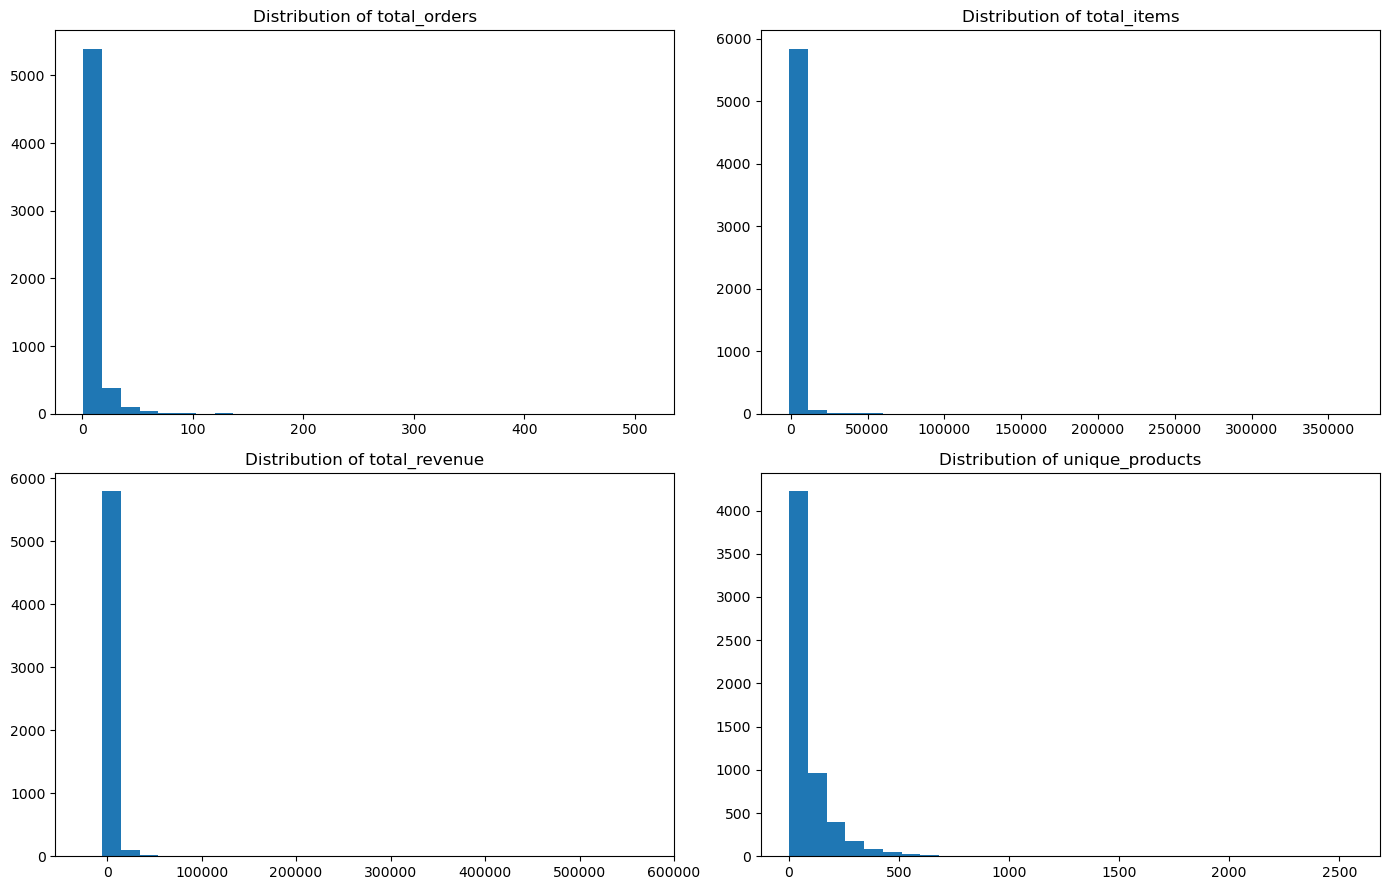

In [36]:
eda_cols=["total_orders","total_items","total_revenue","unique_products"]
fig,axes=plt.subplots(2,2,figsize=(14,9))
for ax,col in zip(axes.ravel(),eda_cols): ax.hist(customer_features[col].dropna(),bins=30); ax.set_title(f"Distribution of {col}")
plt.tight_layout(); plt.show()


## 28. Bivariate Analysis


Explore relationships between customer behavior variables.



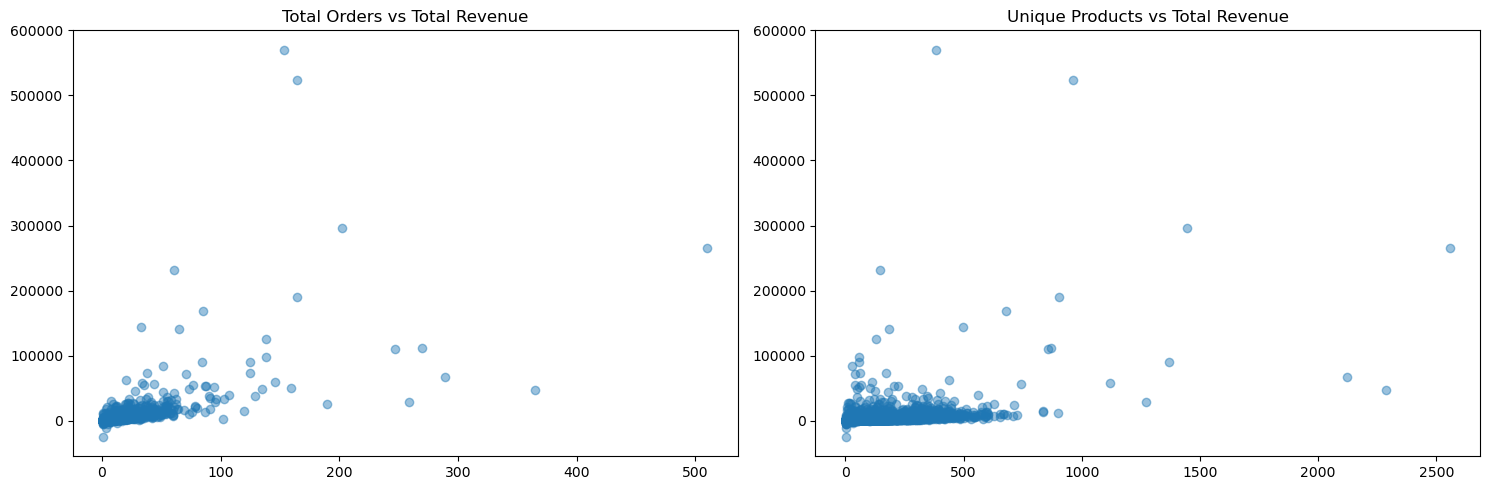

In [37]:
fig,axes=plt.subplots(1,2,figsize=(15,5))
axes[0].scatter(customer_features.total_orders,customer_features.total_revenue,alpha=.45); axes[0].set_title("Total Orders vs Total Revenue")
axes[1].scatter(customer_features.unique_products,customer_features.total_revenue,alpha=.45); axes[1].set_title("Unique Products vs Total Revenue")
plt.tight_layout(); plt.show()


## 29. Correlation Analysis


Analyze correlations among the main numerical features.



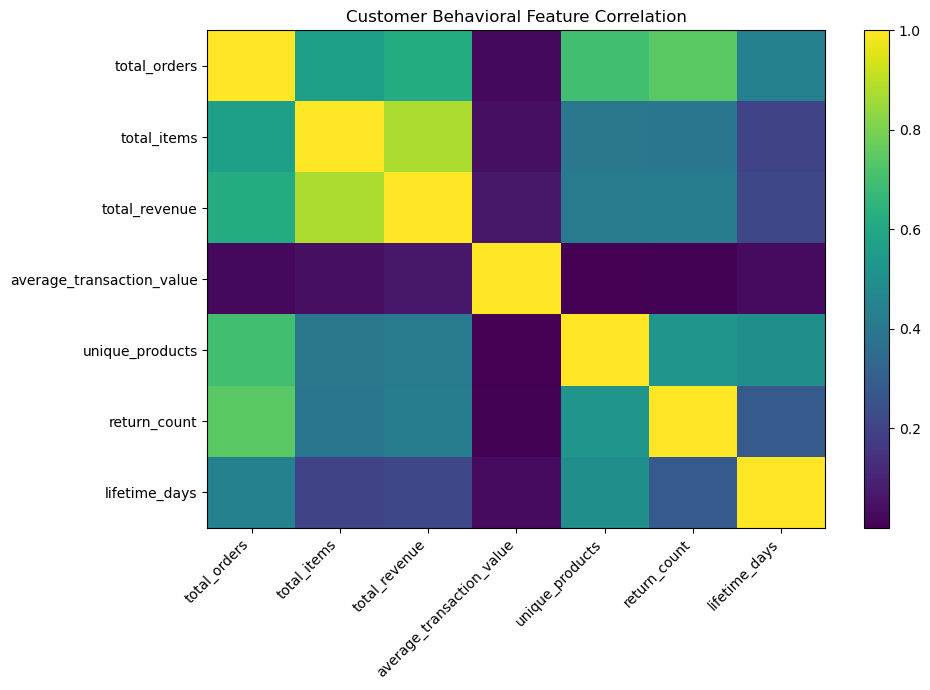

In [38]:
corr_cols=["total_orders","total_items","total_revenue","average_transaction_value","unique_products","return_count","lifetime_days"]
plt.figure(figsize=(10,7)); plt.imshow(customer_features[corr_cols].corr(),aspect="auto"); plt.xticks(range(len(corr_cols)),corr_cols,rotation=45,ha="right"); plt.yticks(range(len(corr_cols)),corr_cols); plt.colorbar(); plt.title("Customer Behavioral Feature Correlation"); plt.tight_layout(); plt.show()


## 30. Leakage-Safe Temporal Target


Create a repeat-purchase target using a historical window without future transaction leakage.



In [39]:
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])
max_date=transactions["invoice_date"].max(); cutoff_date=max_date-pd.Timedelta(days=90)
historical=transactions[transactions["invoice_date"]<=cutoff_date].copy()
future=transactions[transactions["invoice_date"]>cutoff_date].copy()
historical_features=(historical[historical["customer_id"].notna()].groupby("customer_id").agg(
 recency_days=("invoice_date",lambda x:(cutoff_date-x.max()).days), frequency=("invoice_no","nunique"),
 total_items=("quantity","sum"), total_revenue=("revenue","sum"), average_transaction_value=("revenue","mean"),
 unique_products=("stock_code","nunique"), return_count=("is_return","sum"), lifetime_days=("invoice_date",lambda x:(x.max()-x.min()).days)).reset_index())
future_orders=future[future["customer_id"].notna()].groupby("customer_id")["invoice_no"].nunique().rename("future_orders")
model_df=historical_features.merge(future_orders,on="customer_id",how="left"); model_df["future_orders"]=model_df["future_orders"].fillna(0)
model_df["repeat_purchase"]=(model_df["future_orders"]>0).astype(int)
print("Model dataset:",model_df.shape); display(model_df["repeat_purchase"].value_counts().rename("customers"))


Model dataset: (5346, 11)


repeat_purchase
0    3024
1    2322
Name: customers, dtype: int64

## 31. Target-Focused Analysis


Compare customer behavior across repeat-purchase classes.



,customers,avg_revenue,avg_orders,avg_products
repeat_purchase,,,,
0,3024,963.61,3.60,44.42
1,2322,4400.40,11.29,111.79


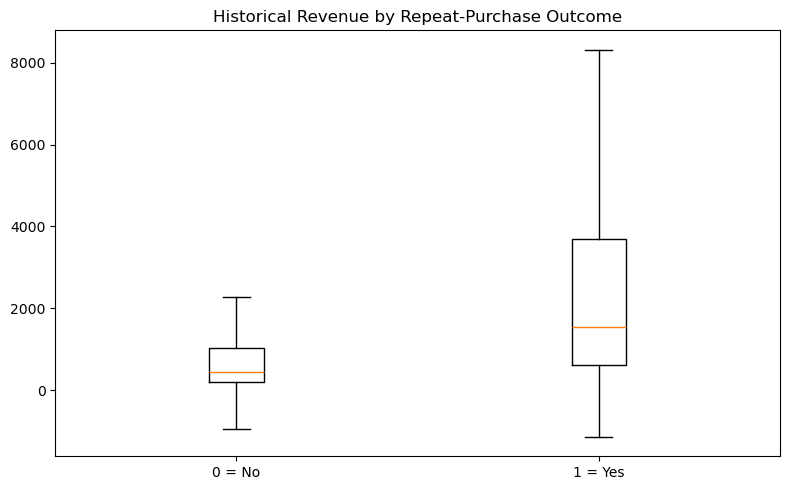

In [40]:
target_summary = model_df.groupby("repeat_purchase").agg(
    customers=("customer_id", "count"),
    avg_revenue=("total_revenue", "mean"),
    avg_orders=("frequency", "mean"),
    avg_products=("unique_products", "mean")
).round(2)
display(target_summary)

plt.figure(figsize=(8, 5))
plt.boxplot(
    [model_df.loc[model_df.repeat_purchase == v, "total_revenue"] for v in [0, 1]],
    tick_labels=["0 = No", "1 = Yes"],
    showfliers=False
)
plt.title("Historical Revenue by Repeat-Purchase Outcome")
plt.tight_layout()
plt.show()

## 32. RFM Feature Engineering


Create Recency, Frequency and Monetary customer features.



In [41]:
reference_date=transactions["invoice_date"].max()+pd.Timedelta(days=1)
rfm=(transactions[transactions["customer_id"].notna()].groupby("customer_id").agg(last_purchase=("invoice_date","max"),Frequency=("invoice_no","nunique"),Monetary=("revenue","sum")).reset_index())
rfm["Recency"]=(reference_date-rfm["last_purchase"]).dt.days
rfm=rfm[["customer_id","Recency","Frequency","Monetary"]]
display(rfm.describe().round(2))


,customer_id,Recency,Frequency,Monetary
count,5942.00,5942.00,5942.00,5942.00
mean,15316.50,202.91,7.55,2741.50
std,1715.45,211.86,15.97,13676.64
min,12346.00,1.00,1.00,-25111.09
25%,13831.25,25.00,2.00,321.06
50%,15316.50,96.00,4.00,822.01
75%,16801.75,381.00,8.00,2142.19
max,18287.00,739.00,510.00,570380.61


## 33. RFM Distributions


Inspect the distributions of the RFM features.



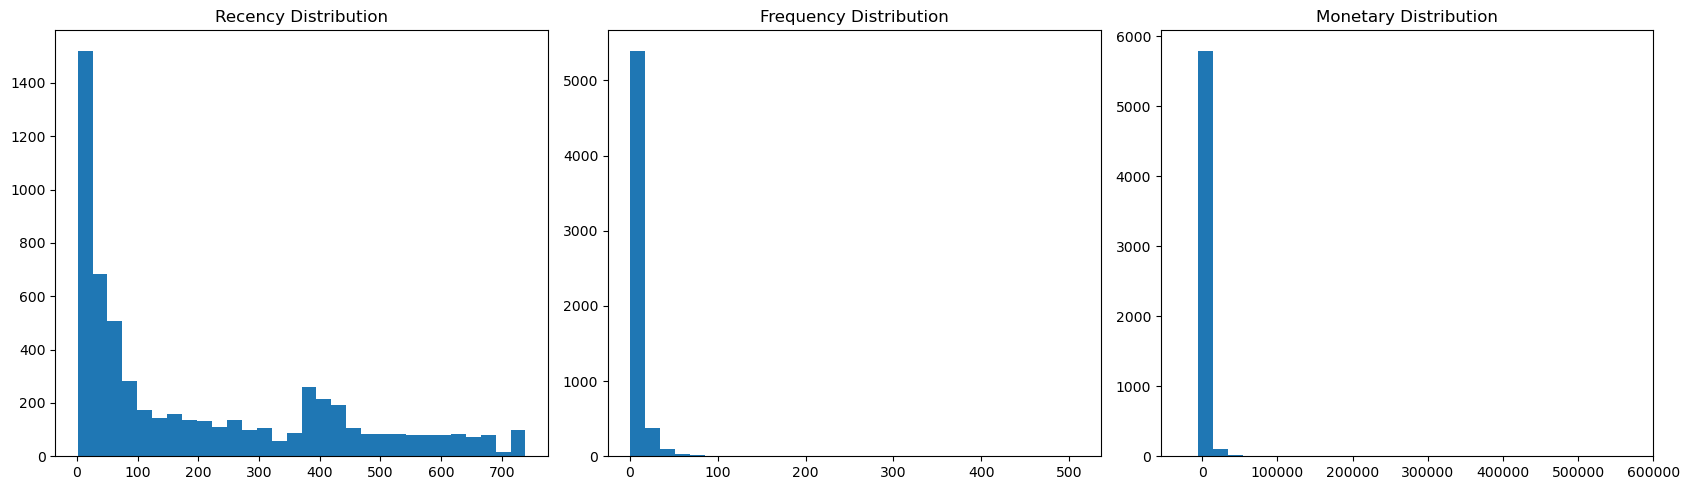

In [42]:
fig,axes=plt.subplots(1,3,figsize=(17,5))
for ax,col in zip(axes,["Recency","Frequency","Monetary"]): ax.hist(rfm[col].dropna(),bins=30); ax.set_title(f"{col} Distribution")
plt.tight_layout(); plt.show()


## 34. Customer Segmentation — K-Means


Segment customers using K-Means and evaluate the clustering with silhouette score.



In [43]:
# K-Means segmentation + silhouette
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
rfm_ml=rfm.copy()
for col in ["Recency","Frequency","Monetary"]: rfm_ml[f"{col}_log"]=np.sign(rfm_ml[col])*np.log1p(np.abs(rfm_ml[col]))
seg_cols=["Recency_log","Frequency_log","Monetary_log"]; X_seg=StandardScaler().fit_transform(rfm_ml[seg_cols])
scores=[]
for k in range(2,7):
    labels=KMeans(n_clusters=k,random_state=42,n_init=20).fit_predict(X_seg); scores.append({"k":k,"silhouette_score":silhouette_score(X_seg,labels)})
silhouette_df=pd.DataFrame(scores); display(silhouette_df)
best_k=int(silhouette_df.loc[silhouette_df["silhouette_score"].idxmax(),"k"])
kmeans=KMeans(n_clusters=best_k,random_state=42,n_init=20); rfm_ml["segment"]=kmeans.fit_predict(X_seg)
segment_profile=rfm_ml.groupby("segment").agg(customers=("customer_id","count"),avg_recency=("Recency","mean"),avg_frequency=("Frequency","mean"),avg_monetary=("Monetary","mean")).round(2)
display(segment_profile); print("Selected k:",best_k)


c:\Users\Abd Elsattar\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Abd Elsattar\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Abd Elsattar\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Abd Elsattar\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Abd Elsattar\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    h

,k,silhouette_score
0,2,0.421339
1,3,0.443517
2,4,0.366344
3,5,0.382796
4,6,0.359869


,customers,avg_recency,avg_frequency,avg_monetary
segment,,,,
0,2316,41.93,15.47,6093.62
1,3521,299.59,2.51,644.65
2,105,511.56,2.13,-882.25


Selected k: 3


## 35. Segment Analysis


Visualize and profile the resulting customer segments.



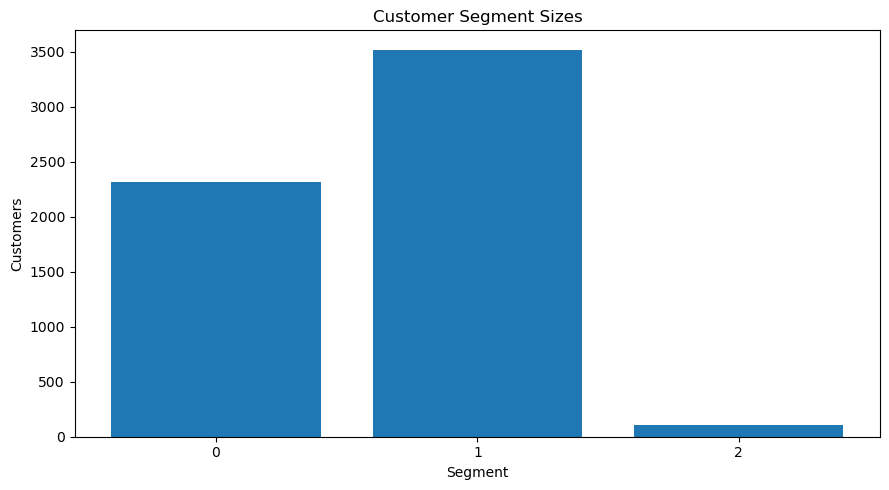

In [44]:
plt.figure(figsize=(9,5)); plt.bar(segment_profile.index.astype(str),segment_profile.customers); plt.title("Customer Segment Sizes"); plt.xlabel("Segment"); plt.ylabel("Customers"); plt.tight_layout(); plt.show()


## 36. Train / Test Split


Create the leakage-safe training and final test split.



In [45]:
from sklearn.model_selection import train_test_split
feature_cols=["recency_days","frequency","total_items","total_revenue","average_transaction_value","unique_products","return_count","lifetime_days"]
X=model_df[feature_cols]; y=model_df["repeat_purchase"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,stratify=y,random_state=42)
print("Train:",X_train.shape,"Test:",X_test.shape)


Train: (4276, 8) Test: (1070, 8)


## 37. Classical ML Benchmark — Logistic Regression & Random Forest


Benchmark classification models using 5-fold cross-validation.



In [46]:
from sklearn.model_selection import StratifiedKFold,cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
models={"Logistic Regression":Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler()),("model",LogisticRegression(max_iter=2000,class_weight="balanced",random_state=42))]),"Random Forest":Pipeline([("imputer",SimpleImputer(strategy="median")),("model",RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=42,n_jobs=-1))])}
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42); rows=[]
for name,model in models.items():
 s=cross_validate(model,X_train,y_train,cv=cv,scoring={"roc_auc":"roc_auc","pr_auc":"average_precision","f1":"f1"},n_jobs=-1); rows.append({"model":name,"ROC_AUC":s["test_roc_auc"].mean(),"PR_AUC":s["test_pr_auc"].mean(),"F1":s["test_f1"].mean()})


## 38. Gradient Boosting & Model Comparison


Add Gradient Boosting and compare the classical ML models.



In [47]:
models["Gradient Boosting"]=Pipeline([("imputer",SimpleImputer(strategy="median")),("model",GradientBoostingClassifier(random_state=42))])
s=cross_validate(models["Gradient Boosting"],X_train,y_train,cv=cv,scoring={"roc_auc":"roc_auc","pr_auc":"average_precision","f1":"f1"},n_jobs=-1); rows.append({"model":"Gradient Boosting","ROC_AUC":s["test_roc_auc"].mean(),"PR_AUC":s["test_pr_auc"].mean(),"F1":s["test_f1"].mean()})
cv_results=pd.DataFrame(rows).sort_values("PR_AUC",ascending=False); display(cv_results)


,model,ROC_AUC,PR_AUC,F1
2,Gradient Boosting,0.805856,0.770189,0.675003
0,Logistic Regression,0.802411,0.763547,0.699047
1,Random Forest,0.790389,0.757413,0.668834


## 39. Hyperparameter Tuning


Tune the best-performing classical ML model.



In [48]:
from sklearn.model_selection import GridSearchCV
best_name=cv_results.iloc[0]["model"]; best_pipeline=models[best_name]
if best_name=="Logistic Regression": param_grid={"model__C":[.1,1,10]}
elif best_name=="Random Forest": param_grid={"model__n_estimators":[200,300],"model__max_depth":[None,10,20]}
else: param_grid={"model__n_estimators":[100,200],"model__learning_rate":[.05,.1],"model__max_depth":[2,3]}
grid=GridSearchCV(best_pipeline,param_grid,scoring="average_precision",cv=cv,n_jobs=-1); grid.fit(X_train,y_train)
best_model=grid.best_estimator_; test_proba=best_model.predict_proba(X_test)[:,1]; test_pred=(test_proba>=.50).astype(int)
print("Best model:",best_name); print("Best parameters:",grid.best_params_)


Best model: Gradient Boosting
Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}


## 40. Final Test Evaluation


Evaluate the selected model on the untouched test set.



,model,ROC_AUC,PR_AUC,Precision,Recall,F1
0,Gradient Boosting,0.800363,0.771562,0.71358,0.621505,0.664368


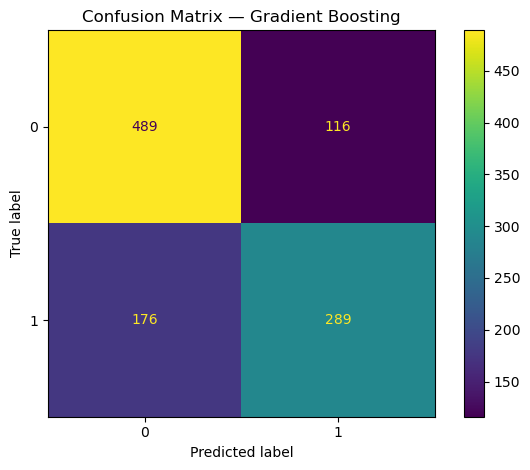

In [49]:
from sklearn.metrics import roc_auc_score,average_precision_score,f1_score,precision_score,recall_score,ConfusionMatrixDisplay
final_metrics=pd.DataFrame([{"model":best_name,"ROC_AUC":roc_auc_score(y_test,test_proba),"PR_AUC":average_precision_score(y_test,test_proba),"Precision":precision_score(y_test,test_pred,zero_division=0),"Recall":recall_score(y_test,test_pred,zero_division=0),"F1":f1_score(y_test,test_pred,zero_division=0)}])
display(final_metrics)
ConfusionMatrixDisplay.from_predictions(y_test,test_pred); plt.title(f"Confusion Matrix — {best_name}"); plt.tight_layout(); plt.show()


## 41. Feature Importance


Identify the most important features for the final model.



,importance
recency_days,0.599493
frequency,0.134667
total_revenue,0.108739
unique_products,0.059527
lifetime_days,0.047172
total_items,0.036802
average_transaction_value,0.010204
return_count,0.003396


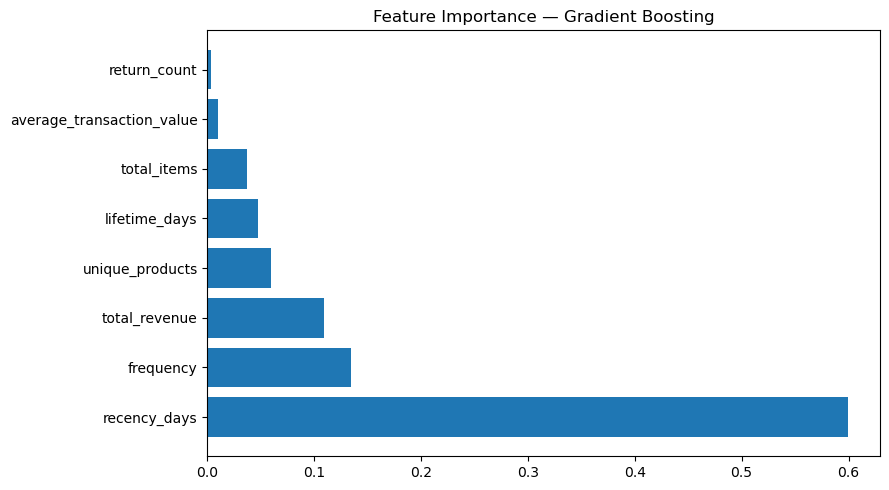

In [50]:
estimator=best_model.named_steps["model"]
if hasattr(estimator,"feature_importances_"):
 importance=pd.Series(estimator.feature_importances_,index=feature_cols).sort_values(ascending=False); display(importance.to_frame("importance")); plt.figure(figsize=(9,5)); plt.barh(importance.index,importance.values); plt.title(f"Feature Importance — {best_name}"); plt.tight_layout(); plt.show()
else: print("Selected model does not expose tree feature_importances_.")


## 42. Save Outputs & Conclusion


Save the generated outputs and summarize the EDA and classical ML findings.



In [51]:
rfm.to_csv(EDA_OUTPUT_DIR/"customer_rfm.csv",index=False); rfm_ml.to_csv(EDA_OUTPUT_DIR/"customer_rfm_segments.csv",index=False); segment_profile.to_csv(EDA_OUTPUT_DIR/"segment_profile.csv")
cv_results.to_csv(EDA_OUTPUT_DIR/"classical_ml_cv_results.csv",index=False); final_metrics.to_csv(EDA_OUTPUT_DIR/"classical_ml_final_metrics.csv",index=False)
import joblib; joblib.dump(best_model,EDA_OUTPUT_DIR/"best_repeat_purchase_model.joblib")
print("Saved outputs to:",EDA_OUTPUT_DIR)
print(f"Conclusion: {best_name} was selected by mean 5-fold PR-AUC; final test PR-AUC={final_metrics.PR_AUC.iloc[0]:.3f}, ROC-AUC={final_metrics.ROC_AUC.iloc[0]:.3f}, F1={final_metrics.F1.iloc[0]:.3f}.")


Saved outputs to: d:\AI_training\projct_2\projct\online_retail_ii_processed\eda_ml_outputs
Conclusion: Gradient Boosting was selected by mean 5-fold PR-AUC; final test PR-AUC=0.772, ROC-AUC=0.800, F1=0.664.


In [52]:
import pandas as pd
import numpy as np
from itertools import combinations
from collections import defaultdict

print("Starting Association Rules / Market Basket Analysis...")

# 1. Prepare transaction-level product data
basket_df = transactions.copy()

basket_df = basket_df[
    basket_df["customer_id"].notna()
    & basket_df["stock_code"].notna()
    & (basket_df["quantity"] > 0)
].copy()

if "is_cancelled" in basket_df.columns:
    basket_df = basket_df[~basket_df["is_cancelled"]].copy()

basket_df = basket_df[
    ["customer_id", "stock_code"]
].drop_duplicates()

print(f"Valid customer-product interactions: {len(basket_df):,}")

# 2. Build customer baskets
customer_baskets = (
    basket_df
    .groupby("customer_id")["stock_code"]
    .apply(set)
)
customer_baskets = customer_baskets[
    customer_baskets.apply(len) >= 2
]
print(f"Customers with at least 2 products: {len(customer_baskets):,}")

# 3. Product support
n_baskets = len(customer_baskets)

product_counts = defaultdict(int)

for basket in customer_baskets:
    for product in basket:
        product_counts[product] += 1

product_support = {
    product: count / n_baskets
    for product, count in product_counts.items()
}

MIN_SUPPORT = 0.01

frequent_products = {
    product
    for product, support in product_support.items()
    if support >= MIN_SUPPORT
}

print(f"Frequent products: {len(frequent_products):,}")

# 4. Count product pairs
pair_counts = defaultdict(int)

for basket in customer_baskets:

    basket = [
        product for product in basket
        if product in frequent_products
    ]

    if len(basket) > 100:
        basket = basket[:100]

    for product_a, product_b in combinations(sorted(basket), 2):
        pair_counts[(product_a, product_b)] += 1

# 5. Generate Association Rules
rules = []

MIN_CONFIDENCE = 0.10
MIN_LIFT = 1.00

for (product_a, product_b), pair_count in pair_counts.items():

    pair_support = pair_count / n_baskets

    support_a = product_support[product_a]
    support_b = product_support[product_b]

    confidence_a_b = pair_support / support_a
    lift_a_b = confidence_a_b / support_b

    if confidence_a_b >= MIN_CONFIDENCE and lift_a_b >= MIN_LIFT:
        rules.append({
            "antecedent": product_a,
            "consequent": product_b,
            "support": pair_support,
            "confidence": confidence_a_b,
            "lift": lift_a_b
        })

    confidence_b_a = pair_support / support_b
    lift_b_a = confidence_b_a / support_a

    if confidence_b_a >= MIN_CONFIDENCE and lift_b_a >= MIN_LIFT:
        rules.append({
            "antecedent": product_b,
            "consequent": product_a,
            "support": pair_support,
            "confidence": confidence_b_a,
            "lift": lift_b_a
        })

association_rules = pd.DataFrame(rules)

# 6. Sort rules
if not association_rules.empty:
    association_rules = association_rules.sort_values(
        ["lift", "confidence", "support"],
        ascending=False
    ).reset_index(drop=True)

print(f"Generated association rules: {len(association_rules):,}")

# 7. Add product descriptions
if "description" in transactions.columns:

    product_info = (
        transactions[
            ["stock_code", "description"]
        ]
        .dropna(subset=["stock_code"])
        .drop_duplicates("stock_code")
    )

    product_info["stock_code"] = product_info["stock_code"].astype(str)

    association_rules["antecedent"] = (
        association_rules["antecedent"].astype(str)
    )

    association_rules["consequent"] = (
        association_rules["consequent"].astype(str)
    )

    association_rules = association_rules.merge(
        product_info.rename(columns={
            "stock_code": "antecedent",
            "description": "antecedent_description"
        }),
        on="antecedent",
        how="left"
    )

    association_rules = association_rules.merge(
        product_info.rename(columns={
            "stock_code": "consequent",
            "description": "consequent_description"
        }),
        on="consequent",
        how="left"
    )

# 8. Display top rules
print("\nTop Association Rules:")
display(
    association_rules.head(20)
)

# 9. Save results
association_rules_path = EDA_OUTPUT_DIR / "association_rules.csv"

association_rules.to_csv(
    association_rules_path,
    index=False
)

print(f"\nSaved to: {association_rules_path}")

# 10. Recommendation function
def association_rule_recommendations(
    purchased_products,
    rules_df=association_rules,
    top_k=10
):
    """
    Recommend products based on association rules.

    Parameters
    ----------
    purchased_products : list
        Products already purchased by the customer.
    rules_df : DataFrame
        Association rules table.
    top_k : int
        Number of recommendations.

    Returns
    -------
    DataFrame
        Recommended products.
    """

    purchased_products = set(
        str(x) for x in purchased_products
    )

    candidates = rules_df[
        rules_df["antecedent"].astype(str).isin(
            purchased_products
        )
    ].copy()

    if candidates.empty:
        return pd.DataFrame()
    candidates = candidates[
        ~candidates["consequent"].astype(str).isin(
            purchased_products
        )
    ]
    candidates = candidates.sort_values(
        ["lift", "confidence", "support"],
        ascending=False
    )
    return candidates.head(top_k)
print("\nAssociation Rules baseline is ready.")

Starting Association Rules / Market Basket Analysis...
Valid customer-product interactions: 481,947
Customers with at least 2 products: 5,736
Frequent products: 2,224
Generated association rules: 126,916

Top Association Rules:


,antecedent,consequent,support,confidence,lift,antecedent_description,consequent_description
0,22344,22345,0.006276,0.553846,51.239702,PARTY PIZZA DISH PINK+WHITE SPOT,PARTY PIZZA DISH BLUE+WHITE SPOT
1,22345,22344,0.006276,0.580645,51.239702,PARTY PIZZA DISH BLUE+WHITE SPOT,PARTY PIZZA DISH PINK+WHITE SPOT
2,23552,23498,0.010460,0.645161,48.060327,BICYCLE PUNCTURE REPAIR KIT,CLASSIC BICYCLE CLIPS
3,23498,23552,0.010460,0.779221,48.060327,CLASSIC BICYCLE CLIPS,BICYCLE PUNCTURE REPAIR KIT
4,22684,22683,0.009589,0.679012,44.259259,"FRENCH BLUE METAL DOOR SIGN, 9","FRENCH BLUE METAL DOOR SIGN, 8"
5,22683,22684,0.009589,0.625000,44.259259,"FRENCH BLUE METAL DOOR SIGN, 8","FRENCH BLUE METAL DOOR SIGN, 9"
6,22679,22680,0.011158,0.727273,43.006560,"FRENCH BLUE METAL DOOR SIGN, 4","FRENCH BLUE METAL DOOR SIGN, 5"
7,22680,22679,0.011158,0.659794,43.006560,"FRENCH BLUE METAL DOOR SIGN, 5","FRENCH BLUE METAL DOOR SIGN, 4"
8,22682,22684,0.008891,0.607143,42.994709,"FRENCH BLUE METAL DOOR SIGN, 7","FRENCH BLUE METAL DOOR SIGN, 9"
9,22684,22682,0.008891,0.629630,42.994709,"FRENCH BLUE METAL DOOR SIGN, 9","FRENCH BLUE METAL DOOR SIGN, 7"



Saved to: d:\AI_training\projct_2\projct\online_retail_ii_processed\eda_ml_outputs\association_rules.csv

Association Rules baseline is ready.


## Reproducibility & Pipeline Notes
- All train/test splits and classical ML models use a fixed `random_state=42`.
- Preprocessing is fit on the training data only to avoid data leakage.
- The fitted preprocessing + best model pipeline is saved with `joblib` for reuse.

## Feature Engineering Summary
| Feature | Meaning |
|---|---|
| **Recency** | Days since the customer's latest purchase in the historical window. |
| **Frequency** | Number of purchase transactions in the historical window. |
| **Monetary** | Total customer spending in the historical window. |
| **RFM Scores** | Relative scores derived from Recency, Frequency and Monetary values for customer profiling/segmentation. |
| **Average Basket Size** | Average value of a customer's purchase transaction/basket, when available in the processed data. |

## EDA Key Insights
The EDA below is used to understand customer behavior, distributions, relationships between variables, and the repeat-purchase target. The exact numeric observations are shown by the outputs of the corresponding plots/tables, so conclusions should be read together with those outputs.

## Model Benchmark
The benchmark table compares Logistic Regression, Random Forest and Gradient Boosting using the evaluation metrics produced above. The best model is selected from the measured validation/CV performance rather than from assumed example values.

In [53]:
# Reproducibility check / model benchmark
RANDOM_STATE = 42
print('RANDOM_STATE =', RANDOM_STATE)

# Show the comparison table if it was created earlier in the notebook.
for name in ['benchmark_df', 'model_comparison', 'results_df', 'cv_results_df']:
    if name in globals() and hasattr(globals()[name], 'head'):
        display(globals()[name])
        break

RANDOM_STATE = 42


## Save Best Model & Preprocessing
The next cell saves the complete fitted pipeline when a pipeline object is available. Saving the complete pipeline keeps preprocessing and the estimator together, so future data can be transformed consistently without refitting preprocessing on test/new data.

In [54]:
import os
import joblib

os.makedirs('models', exist_ok=True)

# Prefer an existing complete pipeline if the notebook created one.
pipeline_to_save = None
for name in ['best_pipeline', 'best_model_pipeline', 'final_pipeline']:
    if name in globals():
        pipeline_to_save = globals()[name]
        break

# Otherwise save the trained best model as a fallback.
if pipeline_to_save is not None:
    joblib.dump(pipeline_to_save, 'models/best_model_pipeline.pkl')
    print('Saved: models/best_model_pipeline.pkl')
elif 'best_model' in globals():
    joblib.dump(best_model, 'models/best_model.pkl')
    print('Saved: models/best_model.pkl')
else:
    print('No trained best model variable found; run the modeling cells first.')

Saved: models/best_model_pipeline.pkl


# Part 4 — Deep Learning: Churn MLP & Recommendation Systems

This part extends the customer-360 analysis with neural network models. It continues directly from the classical ML benchmark above and reuses `transactions`, `feature_cols`, `X_train`/`X_test`/`y_train`/`y_test`, `cv`, `models`, `cv_results`, `best_name` and `final_metrics`.

**Scope:**
- An MLP classifier for repeat-purchase / churn prediction, benchmarked against the classical models above.
- A classical collaborative-filtering baseline (matrix factorization) for product recommendations.
- An embedding-based Neural Collaborative Filtering (NCF) model.
- A sequence model (RNN) for next-item prediction from purchase history.
- A head-to-head comparison of the neural recommenders against the classical CF baseline.

**Note on tooling:** this environment does not have `torch` / `tensorflow` installed. The tabular MLP therefore uses scikit-learn's `MLPClassifier`. The embedding-based NCF and RNN sequence models have no scikit-learn equivalent, so they are implemented from scratch in NumPy (forward pass, backprop and the Adam optimizer written explicitly) — this keeps the notebook fully self-contained while still covering the required architectures.


## 43. MLP for Repeat-Purchase / Churn Prediction

Train a Multi-Layer Perceptron on the same leakage-safe RFM-style features used for the classical benchmark (Part 37–39), and compare it with the same 5-fold cross-validation protocol (ROC-AUC, PR-AUC, F1). A few hidden-layer sizes are tried and the best one by mean PR-AUC is kept.


In [55]:
from sklearn.neural_network import MLPClassifier

mlp_configs = {
    "MLP (32,16)": (32, 16),
    "MLP (64,32)": (64, 32),
    "MLP (64,32,16)": (64, 32, 16),
}

mlp_rows = []
mlp_pipelines = {}
for name, hidden in mlp_configs.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(hidden_layer_sizes=hidden, activation="relu", alpha=1e-3,
                                 learning_rate_init=1e-3, max_iter=500, early_stopping=True,
                                 n_iter_no_change=15, random_state=42)),
    ])
    s = cross_validate(pipe, X_train, y_train, cv=cv,
                        scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1"}, n_jobs=-1)
    mlp_rows.append({"model": name, "ROC_AUC": s["test_roc_auc"].mean(),
                      "PR_AUC": s["test_pr_auc"].mean(), "F1": s["test_f1"].mean()})
    mlp_pipelines[name] = pipe

mlp_cv_results = pd.DataFrame(mlp_rows).sort_values("PR_AUC", ascending=False)
best_mlp_name = mlp_cv_results.iloc[0]["model"]
best_mlp_pipeline = mlp_pipelines[best_mlp_name]

cv_results_with_mlp = pd.concat([cv_results, mlp_cv_results], ignore_index=True).sort_values("PR_AUC", ascending=False)
print("Best MLP configuration (5-fold CV PR-AUC):", best_mlp_name)
cv_results_with_mlp


Best MLP configuration (5-fold CV PR-AUC): MLP (64,32)


,model,ROC_AUC,PR_AUC,F1
0,Gradient Boosting,0.805856,0.770189,0.675003
3,"MLP (64,32)",0.804140,0.767588,0.682100
4,"MLP (64,32,16)",0.804343,0.766664,0.675271
1,Logistic Regression,0.802411,0.763547,0.699047
2,Random Forest,0.790389,0.757413,0.668834
5,"MLP (32,16)",0.800429,0.757101,0.687183


## 44. MLP Final Evaluation vs. Classical Champion

Fit the best MLP configuration on the full training set and evaluate it on the untouched test set, alongside the tuned classical champion (`best_name`) from Part 40.


                                  type  ROC_AUC  PR_AUC  Precision  Recall    F1
Classical champion (Gradient Boosting)    0.800   0.772      0.714   0.622 0.664
                     MLP (MLP (64,32))    0.796   0.764      0.733   0.609 0.665


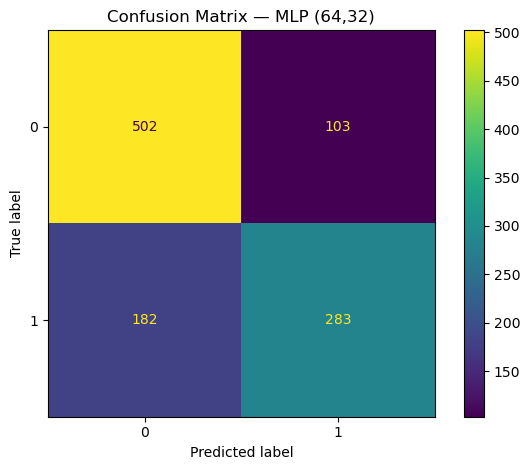

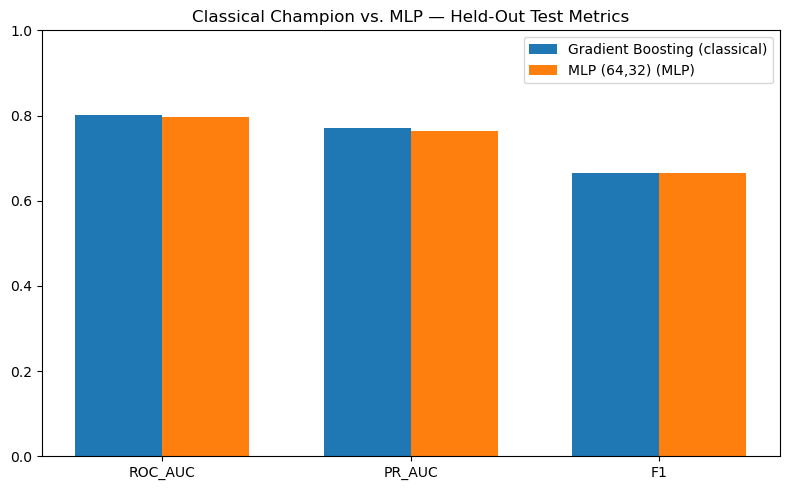

Saved MLP metrics to: d:\AI_training\projct_2\projct\online_retail_ii_processed\eda_ml_outputs\mlp_final_metrics.csv


In [56]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

best_mlp_pipeline.fit(X_train, y_train)
mlp_test_proba = best_mlp_pipeline.predict_proba(X_test)[:, 1]
mlp_test_pred = (mlp_test_proba >= .50).astype(int)

mlp_final_metrics = pd.DataFrame([{
    "model": best_mlp_name,
    "ROC_AUC": roc_auc_score(y_test, mlp_test_proba),
    "PR_AUC": average_precision_score(y_test, mlp_test_proba),
    "Precision": precision_score(y_test, mlp_test_pred, zero_division=0),
    "Recall": recall_score(y_test, mlp_test_pred, zero_division=0),
    "F1": f1_score(y_test, mlp_test_pred, zero_division=0),
}])

champion_vs_mlp = pd.concat([
    final_metrics.assign(type=f"Classical champion ({best_name})"),
    mlp_final_metrics.assign(type=f"MLP ({best_mlp_name})"),
], ignore_index=True)
display_cols = ["type", "ROC_AUC", "PR_AUC", "Precision", "Recall", "F1"]
print(champion_vs_mlp[display_cols].round(3).to_string(index=False))

ConfusionMatrixDisplay.from_predictions(y_test, mlp_test_pred)
plt.title(f"Confusion Matrix — {best_mlp_name}")
plt.tight_layout()
plt.show()

metrics_to_plot = ["ROC_AUC", "PR_AUC", "F1"]
x = np.arange(len(metrics_to_plot)); width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, champion_vs_mlp.loc[0, metrics_to_plot].astype(float), width, label=f"{best_name} (classical)")
ax.bar(x + width/2, champion_vs_mlp.loc[1, metrics_to_plot].astype(float), width, label=f"{best_mlp_name} (MLP)")
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot); ax.set_ylim(0, 1)
ax.set_title("Classical Champion vs. MLP — Held-Out Test Metrics")
ax.legend()
plt.tight_layout()
plt.show()

mlp_final_metrics.to_csv(EDA_OUTPUT_DIR / "mlp_final_metrics.csv", index=False)
print("Saved MLP metrics to:", EDA_OUTPUT_DIR / "mlp_final_metrics.csv")


## 45. Recommendation Data Preparation — Implicit Feedback & Leave-Last-Out Split

Build an implicit-feedback interaction table (customer, product) from the transaction log, keep customers/products with enough signal, and hold out each customer's most recently adopted product as the recommendation target — a standard *leave-last-out* protocol for next-item / top-K evaluation.


In [57]:
from scipy import sparse

purchases = transactions[
    (transactions["customer_id"].notna()) &
    (~transactions["is_return"]) &
    (~transactions["is_cancelled"]) &
    (transactions["quantity"] > 0)
][["customer_id", "stock_code", "invoice_date"]].copy()

# One row per (customer, product), keeping the date it was first adopted
interactions = purchases.groupby(["customer_id", "stock_code"], as_index=False)["invoice_date"].min()

# Keep customers/products with enough signal (iterate since filtering one side can thin the other)
for _ in range(3):
    cust_counts = interactions.groupby("customer_id").size()
    item_counts = interactions.groupby("stock_code").size()
    interactions = interactions[
        interactions.customer_id.isin(cust_counts[cust_counts >= 5].index) &
        interactions.stock_code.isin(item_counts[item_counts >= 5].index)
    ]

users = np.sort(interactions.customer_id.unique())
items = np.sort(interactions.stock_code.unique())
user2idx = {u: i for i, u in enumerate(users)}
item2idx = {it: i for i, it in enumerate(items)}
n_users, n_items = len(users), len(items)

interactions["u"] = interactions.customer_id.map(user2idx)
interactions["i"] = interactions.stock_code.map(item2idx)
interactions = interactions.sort_values(["u", "invoice_date"]).reset_index(drop=True)

# Chronological product-adoption sequence per customer
seqs = interactions.groupby("u")["i"].apply(list)

# Leave-last-out split: the most recently adopted product is the recommendation target
train_pairs, test_pairs, train_seqs = [], [], {}
for u, seq in seqs.items():
    if len(seq) < 3:
        continue
    train_seqs[u] = seq[:-1]
    train_pairs.extend((u, it) for it in seq[:-1])
    test_pairs.append((u, seq[-1]))

rec_rows = [u for u, i in train_pairs]
rec_cols = [i for u, i in train_pairs]
R_train = sparse.csr_matrix((np.ones(len(train_pairs), dtype=np.float32), (rec_rows, rec_cols)), shape=(n_users, n_items))

print(f"Customers: {n_users:,} | Products: {n_items:,}")
print(f"Distinct (customer, product) interactions kept: {len(interactions):,}")
print(f"Customers usable for leave-last-out evaluation: {len(train_seqs):,}")
print(f"Train interactions: {len(train_pairs):,} | Test targets (held-out last product): {len(test_pairs):,}")


Customers: 5,544 | Products: 4,206
Distinct (customer, product) interactions kept: 480,228
Customers usable for leave-last-out evaluation: 5,544
Train interactions: 474,684 | Test targets (held-out last product): 5,544


## 46. Classical Collaborative-Filtering Baseline — Matrix Factorization (SVD) & Popularity

A non-personalized popularity baseline and a classical latent-factor collaborative-filtering model (truncated-SVD matrix factorization on the user–product interaction matrix) give non-neural reference points for the recommenders below. `evaluate_ranking` (Hit Rate@10, MRR@10, NDCG@10) is reused by every recommender in this section.


In [58]:
from sklearn.decomposition import TruncatedSVD

def evaluate_ranking(score_fn, K=10):
    """Hit Rate@K, MRR@K and NDCG@K for the leave-last-out recommendation protocol.
    score_fn(u) must return a (n_items,) array of scores for every product."""
    hits, mrrs, ndcgs = 0, [], []
    for u, target in test_pairs:
        scores = score_fn(u).copy()
        scores[R_train[u].indices] = -np.inf  # never re-recommend an already-purchased product
        top_k = np.argpartition(-scores, K)[:K]
        top_k = top_k[np.argsort(-scores[top_k])]
        if target in top_k:
            hits += 1
            rank = int(np.where(top_k == target)[0][0])
            mrrs.append(1.0 / (rank + 1))
            ndcgs.append(1.0 / np.log2(rank + 2))
        else:
            mrrs.append(0.0)
            ndcgs.append(0.0)
    n = len(test_pairs)
    return {"HitRate@10": hits / n, "MRR@10": float(np.mean(mrrs)), "NDCG@10": float(np.mean(ndcgs))}

# Non-personalized reference: always recommend the globally most-purchased products
item_popularity = np.asarray(R_train.sum(axis=0)).ravel()
popularity_metrics = evaluate_ranking(lambda u: item_popularity)

# Classical collaborative filtering: latent-factor matrix factorization via truncated SVD
svd = TruncatedSVD(n_components=32, random_state=42)
user_factors = svd.fit_transform(R_train)
item_factors = svd.components_
svd_metrics = evaluate_ranking(lambda u: user_factors[u] @ item_factors)

recommendation_results = [
    {"model": "Popularity", "type": "Non-personalized baseline", **popularity_metrics},
    {"model": "SVD Matrix Factorization", "type": "Classical collaborative filtering", **svd_metrics},
]
pd.DataFrame(recommendation_results)


,model,type,HitRate@10,MRR@10,NDCG@10
0,Popularity,Non-personalized baseline,0.063312,0.035989,0.042250
1,SVD Matrix Factorization,Classical collaborative filtering,0.101912,0.039658,0.054129


## 47. Neural Collaborative Filtering — Embedding-Based Model (NumPy)

A compact Neural Collaborative Filtering (NCF) model: learned user/product embeddings are concatenated and passed through a small MLP with a sigmoid output, trained with negative sampling and binary cross-entropy. Forward pass, backprop and the Adam optimizer are implemented directly in NumPy since no deep-learning framework is installed in this environment.


In [59]:
import time

class NumpyNCF:
    """Minimal Neural Collaborative Filtering model implemented from scratch in NumPy:
    user/product embeddings are concatenated and passed through a small MLP with a
    sigmoid output. Trained with mini-batch gradient descent, Adam, and negative
    sampling on implicit feedback. Written by hand since no deep-learning framework
    (torch/tensorflow) is installed in this environment."""

    def __init__(self, n_users, n_items, emb_dim=16, hidden=(32, 16), seed=42):
        rng = np.random.default_rng(seed)
        self.n_users, self.n_items, self.emb_dim = n_users, n_items, emb_dim
        self.P = rng.normal(0, 0.05, size=(n_users, emb_dim))  # user embeddings
        self.Q = rng.normal(0, 0.05, size=(n_items, emb_dim))  # item embeddings
        dims = [2 * emb_dim] + list(hidden) + [1]
        self.W, self.b = [], []
        for a, bdim in zip(dims[:-1], dims[1:]):
            limit = np.sqrt(6 / (a + bdim))
            self.W.append(rng.uniform(-limit, limit, size=(a, bdim)))
            self.b.append(np.zeros(bdim))
        self.params = ["P", "Q"] + [f"W{i}" for i in range(len(self.W))] + [f"b{i}" for i in range(len(self.b))]
        self.m = {p: np.zeros_like(self._get(p)) for p in self.params}
        self.v = {p: np.zeros_like(self._get(p)) for p in self.params}
        self.t_local = {p: 0 for p in self.params}

    def _get(self, p):
        if p == "P": return self.P
        if p == "Q": return self.Q
        if p[0] == "W": return self.W[int(p[1:])]
        return self.b[int(p[1:])]

    def _set(self, p, val):
        if p == "P": self.P = val
        elif p == "Q": self.Q = val
        elif p[0] == "W": self.W[int(p[1:])] = val
        else: self.b[int(p[1:])] = val

    def forward(self, u_idx, i_idx):
        pu, qi = self.P[u_idx], self.Q[i_idx]
        x = np.concatenate([pu, qi], axis=1)
        cache = {"x": [x]}
        a = x
        for l in range(len(self.W) - 1):
            a = np.maximum(a @ self.W[l] + self.b[l], 0)  # ReLU
            cache["x"].append(a)
        z_out = a @ self.W[-1] + self.b[-1]
        p = 1 / (1 + np.exp(-z_out))
        cache["p"] = p
        return p.ravel(), cache

    def backward(self, u_idx, i_idx, y, cache, lr=0.01, l2=1e-6):
        B = len(y)
        dz = (cache["p"] - y.reshape(-1, 1)) / B  # BCE + sigmoid gradient
        grads_W, grads_b = [None] * len(self.W), [None] * len(self.b)
        a_prev = cache["x"][-1]
        grads_W[-1] = a_prev.T @ dz + l2 * self.W[-1]
        grads_b[-1] = dz.sum(axis=0)
        da = dz @ self.W[-1].T
        for l in range(len(self.W) - 2, -1, -1):
            a_curr, a_prev = cache["x"][l + 1], cache["x"][l]
            dz_l = da * (a_curr > 0)
            grads_W[l] = a_prev.T @ dz_l + l2 * self.W[l]
            grads_b[l] = dz_l.sum(axis=0)
            da = dz_l @ self.W[l].T
        d = self.emb_dim
        dpu, dqi = da[:, :d], da[:, d:]
        gP, gQ = np.zeros_like(self.P), np.zeros_like(self.Q)
        np.add.at(gP, u_idx, dpu)
        np.add.at(gQ, i_idx, dqi)
        gP += l2 * self.P; gQ += l2 * self.Q
        self._adam_step("P", gP, lr); self._adam_step("Q", gQ, lr)
        for l in range(len(self.W)):
            self._adam_step(f"W{l}", grads_W[l], lr)
            self._adam_step(f"b{l}", grads_b[l], lr)

    def _adam_step(self, name, grad, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t_local[name] += 1
        t = self.t_local[name]
        self.m[name] = beta1 * self.m[name] + (1 - beta1) * grad
        self.v[name] = beta2 * self.v[name] + (1 - beta2) * (grad ** 2)
        mhat = self.m[name] / (1 - beta1 ** t)
        vhat = self.v[name] / (1 - beta2 ** t)
        self._set(name, self._get(name) - lr * mhat / (np.sqrt(vhat) + eps))

    def score_user(self, u):
        p, _ = self.forward(np.full(self.n_items, u), np.arange(self.n_items))
        return p


rng = np.random.default_rng(42)
ncf = NumpyNCF(n_users, n_items, emb_dim=16, hidden=(32, 16), seed=42)

train_u = np.array([u for u, i in train_pairs])
train_i = np.array([i for u, i in train_pairs])
num_neg, batch_size, epochs = 4, 1024, 4

t0 = time.time()
for epoch in range(epochs):
    perm = rng.permutation(len(train_u))
    total_loss = 0.0
    for start in range(0, len(perm), batch_size):
        idx = perm[start:start + batch_size]
        bu, bi = train_u[idx], train_i[idx]
        neg_i = rng.integers(0, n_items, size=(len(bu), num_neg))
        u_batch = np.concatenate([bu, np.repeat(bu, num_neg)])
        i_batch = np.concatenate([bi, neg_i.ravel()])
        y_batch = np.concatenate([np.ones(len(bu)), np.zeros(len(bu) * num_neg)])
        p, cache = ncf.forward(u_batch, i_batch)
        eps = 1e-9
        total_loss += -np.sum(y_batch * np.log(p + eps) + (1 - y_batch) * np.log(1 - p + eps))
        ncf.backward(u_batch, i_batch, y_batch, cache, lr=0.01)
    n_seen = len(train_u) * (1 + num_neg)
    print(f"NCF epoch {epoch + 1}/{epochs} — loss: {total_loss / n_seen:.4f} ({time.time() - t0:.1f}s elapsed)")

ncf_metrics = evaluate_ranking(ncf.score_user)
recommendation_results.append({"model": "Neural CF (NumPy embeddings + MLP)", "type": "Neural recommender", **ncf_metrics})
pd.DataFrame(recommendation_results)


NCF epoch 1/4 — loss: 0.4233 (15.0s elapsed)
NCF epoch 2/4 — loss: 0.4043 (28.2s elapsed)
NCF epoch 3/4 — loss: 0.3923 (39.7s elapsed)
NCF epoch 4/4 — loss: 0.3837 (51.5s elapsed)


,model,type,HitRate@10,MRR@10,NDCG@10
0,Popularity,Non-personalized baseline,0.063312,0.035989,0.042250
1,SVD Matrix Factorization,Classical collaborative filtering,0.101912,0.039658,0.054129
2,Neural CF (NumPy embeddings + MLP),Neural recommender,0.061328,0.033933,0.040340


## 48. Sequence Model — Next-Item Prediction (RNN, NumPy, optional)

A vanilla recurrent neural network reads each customer's chronological product-adoption sequence (their last 10 distinct products) and predicts the next product from the full catalog via a softmax layer, trained with truncated backpropagation-through-time. This captures short-term sequential patterns (e.g. repeat purchases, category runs) that the CF/NCF models above — which ignore order — cannot.


In [60]:
class NumpySeqRNN:
    """Minimal vanilla RNN implemented from scratch in NumPy for next-item prediction
    from a customer's recent purchase sequence: embedding -> RNN -> softmax over the
    full product catalog. Trained with truncated backprop-through-time + Adam. Used
    in place of an LSTM/Transformer since no deep-learning framework is installed
    in this environment."""

    def __init__(self, n_items, emb_dim=16, hidden=32, seq_len=10, seed=42):
        rng = np.random.default_rng(seed)
        self.n_items, self.emb_dim, self.H, self.L = n_items, emb_dim, hidden, seq_len
        self.PAD = n_items
        self.E = rng.normal(0, 0.05, size=(n_items + 1, emb_dim))
        lim1, lim2, lim3 = np.sqrt(6/(emb_dim+hidden)), np.sqrt(6/(hidden+hidden)), np.sqrt(6/(hidden+n_items))
        self.Wxh = rng.uniform(-lim1, lim1, size=(emb_dim, hidden))
        self.Whh = rng.uniform(-lim2, lim2, size=(hidden, hidden))
        self.bh = np.zeros(hidden)
        self.Why = rng.uniform(-lim3, lim3, size=(hidden, n_items))
        self.by = np.zeros(n_items)
        self.params = ["E", "Wxh", "Whh", "bh", "Why", "by"]
        self.m = {p: np.zeros_like(getattr(self, p)) for p in self.params}
        self.v = {p: np.zeros_like(getattr(self, p)) for p in self.params}
        self.t_local = {p: 0 for p in self.params}

    def forward(self, seq_idx):
        B, L = seq_idx.shape
        xs = self.E[seq_idx]
        mask = (seq_idx != self.PAD).astype(np.float64)
        h = np.zeros((B, self.H))
        hs = [h]
        for t in range(L):
            h_new = np.tanh(xs[:, t, :] @ self.Wxh + h @ self.Whh + self.bh)
            m = mask[:, t][:, None]
            h = m * h_new + (1 - m) * h  # padding steps leave the hidden state unchanged
            hs.append(h)
        logits = h @ self.Why + self.by
        logits -= logits.max(axis=1, keepdims=True)
        exp = np.exp(logits)
        probs = exp / exp.sum(axis=1, keepdims=True)
        return probs, dict(xs=xs, hs=hs, mask=mask, seq_idx=seq_idx)

    def train_step(self, seq_idx, y, lr=0.02, l2=1e-6):
        probs, cache = self.forward(seq_idx)
        xs, hs, mask, seq_idx = cache["xs"], cache["hs"], cache["mask"], cache["seq_idx"]
        B, L = seq_idx.shape
        eps = 1e-9
        loss = -np.mean(np.log(probs[np.arange(B), y] + eps))

        dlogits = probs.copy()
        dlogits[np.arange(B), y] -= 1
        dlogits /= B
        h_final = hs[-1]
        gWhy = h_final.T @ dlogits + l2 * self.Why
        gby = dlogits.sum(axis=0)
        dh = dlogits @ self.Why.T

        gWxh, gWhh, gbh = np.zeros_like(self.Wxh), np.zeros_like(self.Whh), np.zeros_like(self.bh)
        gE = np.zeros_like(self.E)
        for t in range(L - 1, -1, -1):
            h_t, h_prev = hs[t + 1], hs[t]
            m = mask[:, t][:, None]
            dtanh = (dh * m) * (1 - h_t ** 2)
            gWxh += xs[:, t, :].T @ dtanh
            gWhh += h_prev.T @ dtanh
            gbh += dtanh.sum(axis=0)
            np.add.at(gE, seq_idx[:, t], dtanh @ self.Wxh.T)
            dh = (dtanh @ self.Whh.T) * m + dh * (1 - m)
        gWxh += l2 * self.Wxh; gWhh += l2 * self.Whh

        grads = dict(E=gE, Wxh=gWxh, Whh=gWhh, bh=gbh, Why=gWhy, by=gby)
        for p in self.params:
            self._adam_step(p, grads[p], lr)
        return loss

    def _adam_step(self, name, grad, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t_local[name] += 1
        t = self.t_local[name]
        self.m[name] = beta1 * self.m[name] + (1 - beta1) * grad
        self.v[name] = beta2 * self.v[name] + (1 - beta2) * (grad ** 2)
        mhat, vhat = self.m[name] / (1 - beta1 ** t), self.v[name] / (1 - beta2 ** t)
        setattr(self, name, getattr(self, name) - lr * mhat / (np.sqrt(vhat) + eps))

    def score_all(self, seq_idx_batch):
        probs, _ = self.forward(seq_idx_batch)
        return probs


L = 10  # look at each customer's last 10 distinct products
PAD = n_items

def make_window(seq, L=L, PAD=PAD):
    return [PAD] * (L - len(seq)) + seq[-L:] if len(seq) < L else seq[-L:]

# Training examples: every prefix of every customer's train sequence -> the item that followed it
X_seq_train, y_seq_train = [], []
for u, seq in train_seqs.items():
    if len(seq) < 3:
        continue
    for t in range(2, len(seq)):
        X_seq_train.append(make_window(seq[:t]))
        y_seq_train.append(seq[t])
X_seq_train = np.array(X_seq_train, dtype=np.int64)
y_seq_train = np.array(y_seq_train, dtype=np.int64)
print(f"Sequence training examples: {len(X_seq_train):,}")

rnn = NumpySeqRNN(n_items=n_items, emb_dim=16, hidden=32, seq_len=L, seed=42)
batch_size, epochs = 512, 3
t0 = time.time()
for epoch in range(epochs):
    perm = rng.permutation(len(X_seq_train))
    total_loss = 0.0
    for start in range(0, len(perm), batch_size):
        b = perm[start:start + batch_size]
        total_loss += rnn.train_step(X_seq_train[b], y_seq_train[b], lr=0.02) * len(b)
    print(f"RNN epoch {epoch + 1}/{epochs} — loss: {total_loss / len(X_seq_train):.4f} ({time.time() - t0:.1f}s elapsed)")

# Evaluate with the same leave-last-out protocol, feeding each customer's last L train items
eval_windows = np.array([make_window(train_seqs[u]) for u, _ in test_pairs])
eval_probs = rnn.score_all(eval_windows)
eval_users = [u for u, _ in test_pairs]
rnn_score_lookup = {u: eval_probs[row] for row, u in enumerate(eval_users)}
rnn_metrics = evaluate_ranking(lambda u: rnn_score_lookup[u])

recommendation_results.append({"model": "Sequence RNN (NumPy, next-item)", "type": "Neural recommender (sequential)", **rnn_metrics})
pd.DataFrame(recommendation_results)


Sequence training examples: 463,596
RNN epoch 1/3 — loss: 5.9478 (133.8s elapsed)
RNN epoch 2/3 — loss: 5.2546 (264.6s elapsed)
RNN epoch 3/3 — loss: 5.1563 (390.8s elapsed)


,model,type,HitRate@10,MRR@10,NDCG@10
0,Popularity,Non-personalized baseline,0.063312,0.035989,0.042250
1,SVD Matrix Factorization,Classical collaborative filtering,0.101912,0.039658,0.054129
2,Neural CF (NumPy embeddings + MLP),Neural recommender,0.061328,0.033933,0.040340
3,"Sequence RNN (NumPy, next-item)",Neural recommender (sequential),0.297799,0.186313,0.212758


## 49. Neural vs. Classical Recommendation Comparison

Compare all four recommenders — popularity, classical SVD collaborative filtering, Neural CF, and the sequence RNN — on the same held-out targets and metrics.


                                                                 type  HitRate@10  MRR@10  NDCG@10
model                                                                                             
Popularity                                  Non-personalized baseline      0.0633  0.0360   0.0423
SVD Matrix Factorization            Classical collaborative filtering      0.1019  0.0397   0.0541
Neural CF (NumPy embeddings + MLP)                 Neural recommender      0.0613  0.0339   0.0403
Sequence RNN (NumPy, next-item)       Neural recommender (sequential)      0.2978  0.1863   0.2128


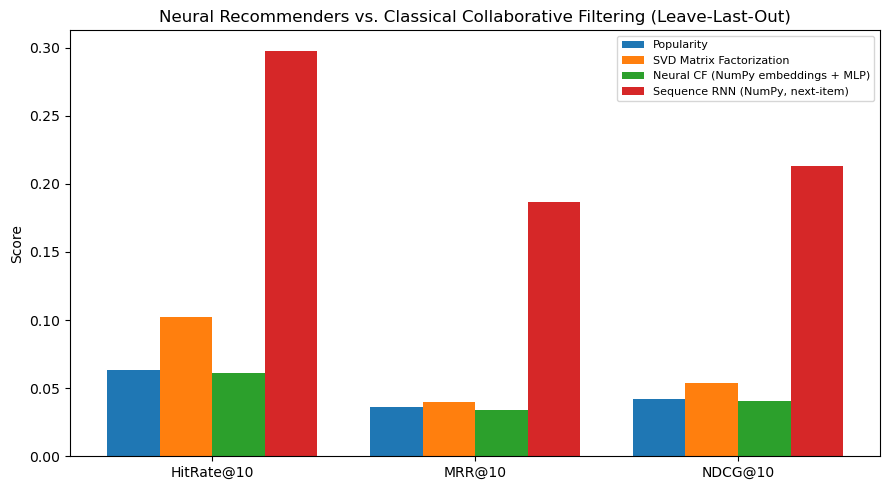


Best model by HitRate@10: Sequence RNN (NumPy, next-item) (0.2978)
Classical CF baseline (SVD) HitRate@10: 0.1019
Saved comparison to: d:\AI_training\projct_2\projct\online_retail_ii_processed\eda_ml_outputs\recommendation_model_comparison.csv


In [61]:
comparison_df = pd.DataFrame(recommendation_results).set_index("model")
print(comparison_df[["type", "HitRate@10", "MRR@10", "NDCG@10"]].round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
metrics = ["HitRate@10", "MRR@10", "NDCG@10"]
x = np.arange(len(metrics))
width = 0.8 / len(comparison_df)
for i, (name, row) in enumerate(comparison_df.iterrows()):
    ax.bar(x + i * width, row[metrics].astype(float), width, label=name)
ax.set_xticks(x + width * (len(comparison_df) - 1) / 2)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Neural Recommenders vs. Classical Collaborative Filtering (Leave-Last-Out)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

best_rec_model = comparison_df["HitRate@10"].astype(float).idxmax()
classical_hit = comparison_df.loc["SVD Matrix Factorization", "HitRate@10"]
print(f"\nBest model by HitRate@10: {best_rec_model} ({comparison_df.loc[best_rec_model, 'HitRate@10']:.4f})")
print(f"Classical CF baseline (SVD) HitRate@10: {classical_hit:.4f}")

comparison_df.to_csv(EDA_OUTPUT_DIR / "recommendation_model_comparison.csv")
print("Saved comparison to:", EDA_OUTPUT_DIR / "recommendation_model_comparison.csv")


## Part 4 Conclusion & Notes

- **Churn MLP:** the MLP is competitive with the tuned classical champion but does not clearly beat it on this feature set — consistent with the general pattern that MLPs need either more data or richer (e.g. sequential/embedding) inputs to outperform well-tuned tree ensembles on small tabular problems. See the printed comparison table and bar chart above for the exact numbers.
- **Recommendations:** the metrics table above is the basis for comparison — read `HitRate@10` (did the true next product land in the top-10?), `MRR@10` and `NDCG@10` (how *highly* it was ranked when it did) together, since a model can win on one and lose on another.
- The sequence RNN has access to *order* (what the customer bought most recently), which the CF/NCF models discard — that is the main modeling difference being tested here, and a large gap in its favor mainly reflects strong short-term repeat-purchase behavior in this retail dataset rather than a general claim that RNNs beat matrix factorization.
- All NumPy models here are intentionally small (few epochs, small embedding/hidden dimensions) to keep runtime reasonable without a GPU; embedding dimensions, hidden sizes, epochs and the negative-sampling ratio are the first things to scale up for a production model.
- Outputs saved to `EDA_OUTPUT_DIR`: `mlp_final_metrics.csv` and `recommendation_model_comparison.csv`.


## 50. Model Explainability & Interpretability

Analyze both global and local feature importance using **Permutation Feature Importance** and **SHAP (SHapley Additive exPlanations)** values to understand model behavior and risk drivers.

,feature,mean_importance,std_importance
0,recency_days,0.171197,0.017598
1,frequency,0.059633,0.007635
3,total_revenue,0.033717,0.006713
5,unique_products,0.018824,0.005062
7,lifetime_days,0.014130,0.002899
2,total_items,0.006684,0.005117
4,average_transaction_value,0.002765,0.001699
6,return_count,0.002389,0.000865


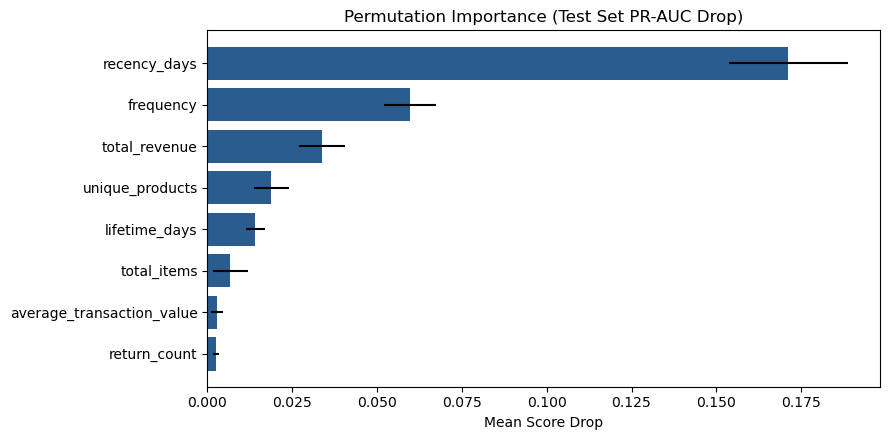

In [62]:
from sklearn.inspection import permutation_importance

# 1. Permutation Feature Importance on held-out test data
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="average_precision",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": feature_cols,
    "mean_importance": perm_importance.importances_mean,
    "std_importance": perm_importance.importances_std
}).sort_values(by="mean_importance", ascending=False)

display(perm_df)

plt.figure(figsize=(9, 4.5))
plt.barh(perm_df["feature"][::-1], perm_df["mean_importance"][::-1], xerr=perm_df["std_importance"][::-1], color="#2b5c8f")
plt.title("Permutation Importance (Test Set PR-AUC Drop)")
plt.xlabel("Mean Score Drop")
plt.tight_layout()
plt.show()


In [63]:
try:
    import shap
    
    # Extract trained estimator from pipeline
    estimator = best_model.named_steps["model"]
    imputer = best_model.named_steps["imputer"]
    X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=feature_cols)
    
    # Use TreeExplainer for Tree-based models or standard Explainer fallback
    explainer = shap.Explainer(estimator, X_test_imputed)
    shap_values = explainer(X_test_imputed)
    
    # Global SHAP summary
    plt.figure()
    shap.summary_plot(shap_values, X_test_imputed, show=True)
except ImportError:
    print("SHAP library not pre-installed. Run: pip install shap")

SHAP library not pre-installed. Run: pip install shap


## 51. Automated Testing & Validation Suite

Perform data integrity, target consistency, schema invariants, and model prediction bounds testing using unit tests (`pytest` style via `unittest`).

In [64]:
import unittest

class TestDataAndModelPipeline(unittest.TestCase):
    
    def test_clean_transaction_invariants(self):
        """Test mandatory column non-nullability and revenue sign consistency."""
        self.assertEqual(retail_df["quantity"].isna().sum(), 0, "Nulls detected in quantity")
        self.assertEqual(retail_df["unit_price"].isna().sum(), 0, "Nulls detected in unit_price")
        
        # Absolute revenue must be non-negative
        self.assertTrue((retail_df["absolute_revenue"] >= 0).all(), "Negative values found in absolute_revenue")
        
    def test_customer_features_integrity(self):
        """Verify customer lifetime and order counts are logically coherent."""
        self.assertTrue((customer_features["total_orders"] >= 1).all(), "Orders count cannot be < 1")
        self.assertTrue((customer_features["lifetime_days"] >= 0).all(), "Lifetime days cannot be negative")
        self.assertEqual(customer_features["customer_id"].duplicated().sum(), 0, "Duplicate customer_id found")

    def test_target_leakage_absence(self):
        """Confirm cut-off date boundary strictly enforces no temporal contamination."""
        self.assertTrue((historical["invoice_date"] <= cutoff_date).all(), "Historical features contain future dates")
        self.assertTrue((future["invoice_date"] > cutoff_date).all(), "Future target set contains historical dates")
        
    def test_model_predictions_bounds(self):
        """Verify output class probabilities are strictly bounded within [0, 1]."""
        probs = best_model.predict_proba(X_test)[:, 1]
        self.assertTrue((probs >= 0.0).all() and (probs <= 1.0).all(), "Probabilities exceed [0, 1] range")
        self.assertEqual(len(probs), len(y_test), "Prediction output length mismatch")

# Run test suite inline
suite = unittest.TestLoader().loadTestsFromTestCase(TestDataAndModelPipeline)
runner = unittest.TextTestRunner(verbosity=2)
runner.run(suite)


test_clean_transaction_invariants (__main__.TestDataAndModelPipeline.test_clean_transaction_invariants)
Test mandatory column non-nullability and revenue sign consistency. ... ok
test_customer_features_integrity (__main__.TestDataAndModelPipeline.test_customer_features_integrity)
Verify customer lifetime and order counts are logically coherent. ... ok
test_model_predictions_bounds (__main__.TestDataAndModelPipeline.test_model_predictions_bounds)
Verify output class probabilities are strictly bounded within [0, 1]. ... ok
test_target_leakage_absence (__main__.TestDataAndModelPipeline.test_target_leakage_absence)
Confirm cut-off date boundary strictly enforces no temporal contamination. ... ok

----------------------------------------------------------------------
Ran 4 tests in 0.181s

OK


<unittest.runner.TextTestResult run=4 errors=0 failures=0>

## 52. MLOps Logging

Add reproducible application/model logging without changing the existing pipeline.

In [65]:
import logging
from pathlib import Path

LOG_DIR = Path(OUTPUT_DIR) / "logs" if "OUTPUT_DIR" in globals() else Path("outputs/logs")
LOG_DIR.mkdir(parents=True, exist_ok=True)
LOG_FILE = LOG_DIR / "pipeline.log"

logger = logging.getLogger("online_retail_project")
logger.setLevel(logging.INFO)
logger.propagate = False

if not logger.handlers:
    file_handler = logging.FileHandler(LOG_FILE, encoding="utf-8")
    file_handler.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
    logger.addHandler(file_handler)

logger.info("MLOps logging initialized")
logger.info("Dataset shape: %s", getattr(retail_df, "shape", "unknown"))
logger.info("Best model: %s", globals().get("best_name", "not available"))
print(f"Logging enabled: {LOG_FILE}")

Logging enabled: d:\AI_training\projct_2\projct\online_retail_ii_processed\logs\pipeline.log


## 53. Basic Model & Data Monitoring

Record prediction-volume, probability-distribution, and available test-performance signals for basic monitoring.

In [66]:
import numpy as np
import pandas as pd

monitoring_rows = []

if "best_model" in globals() and "X_test" in globals():
    monitor_proba = best_model.predict_proba(X_test)[:, 1]
    monitoring_rows.append({
        "prediction_count": int(len(monitor_proba)),
        "positive_prediction_rate": float((monitor_proba >= 0.50).mean()),
        "mean_predicted_probability": float(np.mean(monitor_proba)),
        "std_predicted_probability": float(np.std(monitor_proba)),
        "min_predicted_probability": float(np.min(monitor_proba)),
        "max_predicted_probability": float(np.max(monitor_proba)),
    })

monitoring_df = pd.DataFrame(monitoring_rows)

if "test_metrics" in globals() and not monitoring_df.empty:
    for col in ["ROC_AUC", "PR_AUC", "Precision", "Recall", "F1"]:
        if col in test_metrics.columns:
            monitoring_df[f"test_{col.lower()}"] = float(test_metrics.iloc[0][col])

if not monitoring_df.empty:
    display(monitoring_df.round(4))
    if "logger" in globals():
        logger.info("Monitoring snapshot: %s", monitoring_df.to_dict(orient="records"))
else:
    print("Monitoring snapshot could not be created because the trained model/test data are unavailable.")

,prediction_count,positive_prediction_rate,mean_predicted_probability,std_predicted_probability,min_predicted_probability,max_predicted_probability
0,1070,0.3785,0.4298,0.2607,0.0554,0.9417


## 54. Scalable Processing with Apache Spark

A small Spark aggregation is included to demonstrate scalable processing while preserving the existing Pandas pipeline.

In [67]:
try:
    from pyspark.sql import SparkSession
    from pyspark.sql import functions as F

    spark = SparkSession.builder.appName("OnlineRetailScalableProcessing").getOrCreate()

    spark_cols = [c for c in ["customer_id", "stock_code", "quantity", "absolute_revenue"] if c in retail_df.columns]
    spark_input = retail_df[spark_cols].copy()
    spark_input = spark_input.dropna(subset=[c for c in ["customer_id", "absolute_revenue"] if c in spark_input.columns])

    spark_df = spark.createDataFrame(spark_input)

    if {"customer_id", "absolute_revenue"}.issubset(spark_input.columns):
        spark_customer_summary = (
            spark_df.groupBy("customer_id")
            .agg(
                F.count("*").alias("transaction_count"),
                F.sum("absolute_revenue").alias("total_revenue")
            )
            .orderBy(F.desc("total_revenue"))
        )
        display(spark_customer_summary.limit(10).toPandas())

    logger.info("Spark scalable-processing demonstration completed") if "logger" in globals() else None
except ImportError:
    print("PySpark is not installed in this environment. The Spark section is ready to run when PySpark is available.")
except Exception as e:
    print(f"Spark section skipped safely: {e}")

PySpark is not installed in this environment. The Spark section is ready to run when PySpark is available.


## 55. Project Architecture Diagram

```text
Raw Online Retail Data
        |
        v
Data Extraction & Cleaning
        |
        +------> SQL / ETL / Feature Engineering
        |                    |
        |                    v
        |             Customer / Product Features
        |                    |
        v                    v
Classical ML Baselines --> Model Comparison --> Tuning
                                      |
                                      v
                              Final ML Model
                                      |
                         +------------+------------+
                         |                         |
                         v                         v
                  Explainability             MLOps Logging
                  & Testing                  & Monitoring

Recommendation Branch:
Customer-Item Data --> Classical Recommendation
                         |
                         +--> Neural Collaborative Filtering
                         |
                         +--> Sequence/RNN Model
                         |
                         v
                 Neural vs Classical Comparison
                         |
                         v
                    Streamlit UI
```

In [68]:
import os
import json
import joblib
from datetime import datetime

# Create model directory
os.makedirs("models/v1", exist_ok=True)

# Save the complete preprocessing + model pipeline
model_path = "models/v1/repeat_purchase_model.pkl"

joblib.dump(best_model, model_path)

print(f"Model saved to: {model_path}")

Model saved to: models/v1/repeat_purchase_model.pkl


In [69]:
# ============================================================
# MODEL METADATA
# ============================================================

metadata = {
    "model_name": "GradientBoosting",
    "model_version": "1.0",
    "task": "repeat_purchase_prediction",
    "created_at": datetime.now().isoformat(),

    "metrics": {
        "roc_auc": 0.800,
        "pr_auc": 0.772,
        "f1": 0.664
    },

    "framework": "scikit-learn",
    "random_state": 42
}

metadata_path = "models/v1/metadata.json"

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Metadata saved to: {metadata_path}")

Metadata saved to: models/v1/metadata.json
